# Healthcare Claim Anomaly Detection — Autoencoder (Corrected Pipeline)

**Cameroon openIMIS · 14.24M claim headers · PyTorch**

This notebook is a corrected rebuild of `Healthcare_Claim_Autoencoder_Fraud_Detection.ipynb`.
It covers the **autoencoder track only** — Isolation Forest, LOF, DBSCAN, HDBSCAN and
One-Class SVM are out of scope here (a PCA-reconstruction baseline is included because
without it there is no way to tell whether the depth was necessary).

---

## Defects fixed, mapped to the review

| ID | Defect in the original | Fix in this notebook | Cell |
|---|---|---|---|
| **D1** | `FE_CareType` / `FE_VisitType` / `FE_HFLevel` were constant zero — `to_numeric` on string columns (`OPD/IPD`, `O/R/E`, `D/H/C`) | Treated as genuine categoricals and one-hot encoded; a zero-variance assertion now makes this class of bug fail loudly | §2, §4, §6 |
| **D2** | `Claimed` / `Approved` / `PriceAsked` mass-zeroed by `to_numeric` on space-grouped strings (`5 020`) | `parse_money()` strips unicode separators and reports the unparseable rate; **pre-flight gate halts the run** if parsing fails | §1, §2 |
| **D3** | Target leakage — `Approved`, `Claimed_Minus_Approved`, `Claimed_Ratio` are post-adjudication outcomes; rejection ⇒ 0 XAF approved | `USE_POST_ADJUDICATION_FEATURES = False` by default; a correlation tripwire fails the run if any feature correlates with the label above `LEAKAGE_CORR_LIMIT` | §3, §4 |
| **D4** | `n_train = int(n_total * 0.70)` drawn from `accepted_idx` → test base rate 9.00%, not 2.70%; silent truncation if rejection rate > 30% | Temporal split with explicit base-rate reporting at every stage and guards against empty strata | §5 |
| **D8** | Early stopping on validation loss over a **mixed** set — selects the checkpoint that reconstructs anomalies *well* | Checkpoint selected on **validation PR-AUC of the anomaly score**; loss is reported on an accepted-only slice for diagnostics | §8 |
| **D9** | "Accepted" included never-adjudicated claims (status 2/4/8) whose `Approved` is NULL → 0 | Only fully adjudicated claims kept: accepted ∈ {16, 32}, rejected ∈ {1}; exclusions counted and reported | §2 |
| **D10** | Frequency encodings fitted on the full dataset before splitting | All encoders, target statistics and scalers fitted on **train only**; K-fold out-of-fold target encoding for train rows | §6 |
| **D11** | Latent-dim experiment selected on validation reconstruction MSE (monotone in latent size) and its result was discarded | Sweep selects on **validation PR-AUC** and the winner is used | §9 |
| **D12** | Threshold maximised F1 over a grid truncated at the 85th percentile | Grid widened to the 50th percentile; capacity-constrained, cost-weighted and F-beta options; F1 retained only for comparison | §12 |
| **D13** | `clip(0, ...)` erased negative LOS, backdating and `Approved > Claimed` — the exact signals the features existed to capture | No destructive clipping; `signed_log1p` preserves sign; explicit binary flags for each anomaly condition | §2 |
| **D14** | Random split across a year of data | **Temporal split** by `DateClaimed` (train → val → test, disjoint windows); `SPLIT_MODE='random'` available only for the drift comparison | §5 |
| **D15** | No baseline of any kind | PCA-reconstruction baseline, best-single-feature baseline, random baseline | §14 |
| **D16** | `fillna(0.0)` everywhere — missing became a dense mode the model reconstructs perfectly, so missing data scored as *normal* | Median imputation plus an `_isna` indicator for every imputed field | §2, §6 |
| **D17** | `StandardScaler` on heavy-tailed money, then `clip(±10)` flattening the whole upper tail | `signed_log1p` → `RobustScaler`, no clipping; tail magnitude survives | §6 |
| **D18** | Encoder widened 13→32 before compressing; effective compression 10→8; BatchNorm suppresses anomaly contrast | Genuine bottleneck, BatchNorm off by default, denoising objective to block identity-map learning | §7 |
| **D19** | Facility ranking sorted by mean error with no minimum volume — a 3-claim facility outranks a 30,000-claim facility | Minimum-volume filter plus empirical-Bayes shrinkage toward the global mean | §17 |
| **D20** | ROC/PR curves drawn on 100k rows while the legend showed the full-set AUC; density-normalised histogram hid the imbalance | All curves and all metrics computed on the same full array; histograms on **count** scale with log y | §16 |
| **D21** | Rejection-code breakdown mixed header-level and service-line taxonomies | Observed codes are enumerated from the data before plotting; absent codes are reported, not silently dropped | §15 |
| **D22** | `to_datetime` without `format=` — mixed formats silently became `NaT`, cascading into `LOS=1.0`, `delay=0.0` | Explicit format cascade with a reported NaT rate and a configurable failure threshold | §1, §2 |
| **D23** | `TblHF` merge with no uniqueness check — SCD Type 2 table risks row fan-out | `HfID` uniqueness asserted; row count asserted unchanged after every merge | §2 |
| **D25** | `valid_mask` was dead code after `nan_to_num` — the missing-data audit never ran | Replaced by a real audit gate in §4 | §4 |
| — | Single seed, no variance reported | `N_SEEDS` runs; mean ± std on every headline metric | §10 |
| — | Unweighted mean MSE score | Mahalanobis-weighted score offered alongside; the better of the two chosen **on validation** | §11 |

---

## How to run

1. Set `DATA_DIR` and `MODEL_DIR` in §0.
2. Run §1 first and **read the output**. It is a gate: if money or dates do not parse, the
   notebook raises and you fix the parser config before going further. This is deliberate —
   the original pipeline's worst failures were silent.
3. Run the rest top to bottom.

Set `SAMPLE_FRAC` to something like `0.02` for a fast first pass over the full logic before
committing to a full run.

> **A note on what this model measures.** The target here is `ClaimStatus == 1`, i.e. **claim
> rejection** — not fraud. Per the Data Quality Report's own taxonomy, over 96% of rejections
> are deterministic rule violations (expired policy, invalid ID, demographic mismatch,
> frequency cap) that the openIMIS rules engine already catches with perfect precision at
> submission. Treat every result below as *rejection prediction*, and see §13 of the review
> for why the financial-deduction target (653M XAF across 1.2M accepted claims) and
> provider-level surveillance are the more promising directions.

## §0 — Configuration

In [4]:
import os, gc, json, math, warnings, datetime as _dt
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# ---- repository paths ------------------------------------------------------
# Resolved by walking up from the working directory to the repository root (the
# directory holding both `data/` and `models/`), so the notebook runs unchanged
# from notebooks/ or from the repository root.
_here = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_here, *_here.parents) if (p / "data").is_dir() and (p / "models").is_dir()),
    _here.parent,
)
DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = REPO_ROOT / "models" / "model_autoencoder"
FIGURE_DIR = REPO_ROOT / "figures" / "autoencoder"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # ---- paths -------------------------------------------------------------
    "DATA_DIR":  str(DATA_DIR),
    "MODEL_DIR": str(MODEL_DIR),

    # ---- D9: which claim statuses count as adjudicated ----------------------
    # 1=REJECTED, 2=ENTERED, 4=CHECKED, 8=PROCESSED, 16=VALUATED, 32=PAYMENT
    # Statuses 2/4/8 are in-flight: their `Approved` is NULL and they may still
    # be rejected later. Including them contaminates the "normal" class.
    "ACCEPTED_STATUSES": (16, 32),
    "REJECTED_STATUSES": (1,),

    # ---- D3: post-adjudication features ------------------------------------
    # Approved / Claimed-Approved / Claimed_Ratio are OUTPUTS of adjudication.
    # Rejection means 0 XAF approved, so the label is deterministically
    # recoverable from them. Keep False for any pre-adjudication model.
    # Setting True is only defensible for a post-payment audit model.
    "USE_POST_ADJUDICATION_FEATURES": False,

    # ---- D2/D22: parsing ---------------------------------------------------
    # XAF has no minor unit, so by default every separator is treated as a
    # thousands grouping. Set True only if the export really carries decimals.
    "MONEY_HAS_DECIMALS": False,
    "MAX_MONEY_UNPARSEABLE_RATE": 0.01,   # pre-flight gate
    "MAX_DATE_NAT_RATE":          0.05,   # pre-flight gate

    # ---- D14: split --------------------------------------------------------
    "SPLIT_MODE": "temporal",             # "temporal" (default) | "random" (drift comparison only)
    "SPLIT_DATE_COL": "DateClaimed",
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC":   0.15,                   # test gets the remainder

    # ---- D4/D18: model -----------------------------------------------------
    "LATENT_SWEEP":    (2, 3, 4, 6, 8),
    "LATENT_DIM":      None,              # None => chosen by the §9 sweep
    "HIDDEN":          (32, 16),          # encoder widths before the bottleneck
    "USE_BATCHNORM":   False,             # D18: BN compresses the anomaly gap
    "DROPOUT":         0.0,
    "DENOISE_SIGMA":   0.10,              # D18: blocks identity-map learning
    "BATCH_SIZE":      8192,
    "MAX_EPOCHS":      60,
    "PATIENCE":        8,                 # on validation PR-AUC, not on loss
    "LR":              1e-3,
    "WEIGHT_DECAY":    1e-4,

    # ---- D4: variance ------------------------------------------------------
    "N_SEEDS": 3,
    "SEED":    42,

    # ---- D12: threshold ----------------------------------------------------
    "THRESHOLD_MODE":   "capacity",       # "capacity" | "cost" | "fbeta"
    "AUDIT_CAPACITY_PER_DAY": 500,        # claims auditors can actually review
    "F_BETA":           0.5,              # <1 favours precision
    "COST_FN":          15000.0,          # XAF recovered per caught rejection
    "COST_FP":          2000.0,           # XAF of auditor time per false alarm

    # ---- audit gates -------------------------------------------------------
    "LEAKAGE_CORR_LIMIT": 0.90,           # |corr(feature, y)| above this fails the run
    "MIN_FACILITY_CLAIMS": 100,           # D19

    # ---- runtime -----------------------------------------------------------
    "SAMPLE_FRAC": 1,                   # <1.0 for a fast dry run of the whole logic
    "CHUNK_SIZE":  2_000_000,
    "EXPECTED_CLAIM_ROWS": 14_242_741,    # D23: asserted after every merge
}

DATA_DIR  = Path(CONFIG["DATA_DIR"])
MODEL_DIR = Path(CONFIG["MODEL_DIR"]); MODEL_DIR.mkdir(parents=True, exist_ok=True)
CLAIM_FILE    = DATA_DIR / "TblClaim.csv"
SERVICES_FILE = DATA_DIR / "TblClaimServices.csv"
HF_FILE       = DATA_DIR / "TblHF.csv"

SEED = CONFIG["SEED"]
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {device}")
if device.type == "cuda":
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"\nPost-adjudication features: {'ENABLED (post-payment model)' if CONFIG['USE_POST_ADJUDICATION_FEATURES'] else 'DISABLED (leakage-free)'}")
print(f"Split mode                : {CONFIG['SPLIT_MODE']}")

PyTorch 2.13.0+cpu | device: cpu
pandas 3.0.5 | numpy 2.5.1

Post-adjudication features: DISABLED (leakage-free)
Split mode                : temporal


In [5]:
# ---------------------------------------------------------------------------
# Helper functions: parsing, transforms and audit assertions.
# Every one of these exists because of a specific silent failure in the
# original pipeline. They are loud on purpose.
# ---------------------------------------------------------------------------

_SPACE_CHARS = r"[\s\u00A0\u202F\u2009\u2007]"

def parse_money(s: pd.Series, has_decimals: bool = None) -> pd.Series:
    """D2. Parse a currency column that may be stored as text with unicode
    thousands separators (e.g. '5 020', '1 500', '12\u00a0000').

    The original pipeline used pd.to_numeric(..., errors='coerce').fillna(0.0),
    which turns every value >= 1000 into 0.0 without raising. Returns NaN for
    genuinely unparseable values -- never 0.0, because 0 is a meaningful amount.
    """
    if has_decimals is None:
        has_decimals = CONFIG["MONEY_HAS_DECIMALS"]
    if pd.api.types.is_numeric_dtype(s):
        return s.astype("float64")

    t = s.astype("string").str.strip()
    t = t.str.replace(_SPACE_CHARS, "", regex=True)      # unicode spaces
    t = t.str.replace(r"[^\d\.,\-]", "", regex=True)     # currency symbols, letters

    if has_decimals:
        # Rightmost separator followed by 1-2 digits is the decimal mark.
        t = t.str.replace(r"[\.,](?=\d{3}(?:\D|$))", "", regex=True)
        t = t.str.replace(",", ".", regex=False)
    else:
        t = t.str.replace(r"[\.,]", "", regex=True)      # XAF has no minor unit

    t = t.replace({"": pd.NA, "-": pd.NA})
    return pd.to_numeric(t, errors="coerce").astype("float64")


DATE_FORMATS = [
    "%d %b, %Y, %H:%M", "%d %b, %Y, %H:%M:%S", "%d %b, %Y",
    "%Y-%m-%d %H:%M:%S.%f", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d",
    "%d/%m/%Y %H:%M", "%d/%m/%Y", "%m/%d/%Y",
]

def parse_dates(s: pd.Series, formats=DATE_FORMATS) -> pd.Series:
    """D22. Explicit format cascade instead of per-element inference.

    pd.to_datetime without format= silently returns NaT for the minority format
    when a column mixes two ('2 Apr, 2025' and '9 Apr, 2025, 20:40'), and those
    NaTs then cascaded into LOS=1.0 / delay=0.0 via the original fillna calls.
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return s
    t = s.astype("string").str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    todo = out.isna() & t.notna()
    for fmt in formats:
        if not todo.any():
            break
        parsed = pd.to_datetime(t[todo], format=fmt, errors="coerce")
        out.loc[todo] = parsed
        todo = out.isna() & t.notna()
    if todo.any():                                   # last-resort inference
        try:
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce",
                                           format="mixed", dayfirst=True)
        except (TypeError, ValueError):
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce", dayfirst=True)
    return out


def signed_log1p(x):
    """D13/D17. Compress heavy tails while preserving sign.

    The original clip(0, ...) destroyed exactly the signals the features were
    engineered to detect: negative length-of-stay (1,420 invalid date intervals
    per the DQ report), backdated submissions, and Approved > Claimed.
    """
    x = np.asarray(x, dtype="float64")
    return np.sign(x) * np.log1p(np.abs(x))


def assert_rows(df, expected, label):
    """D23. Merges against SCD Type 2 tables can silently fan out rows."""
    if expected is not None and len(df) != expected:
        raise AssertionError(
            f"[{label}] row count changed: {len(df):,} != {expected:,}. "
            "A merge key is probably non-unique (TblHF is SCD Type 2)."
        )
    print(f"  [ok] {label}: {len(df):,} rows")


def report_series(name, s, n=8):
    nn = s.notna().mean()
    print(f"  {name:<28} dtype={str(s.dtype):<16} non-null={nn:6.2%}  "
          f"sample={list(s.dropna().unique()[:n])}")

print("Helpers loaded: parse_money, parse_dates, signed_log1p, assert_rows, report_series")

Helpers loaded: parse_money, parse_dates, signed_log1p, assert_rows, report_series


## §1 — Pre-flight data integrity gate (D1, D2, D22)

**Read this output before running anything else.**

The two most damaging defects in the original pipeline were invisible: three feature columns
were constant zero and the financial columns were mass-zeroed, and neither raised an error.
This cell samples the raw CSVs, prints the real dtypes and values, and **raises** if money or
dates fail to parse above the configured tolerance.

In [6]:
PREFLIGHT_N = 200_000

print("=" * 78)
print("PRE-FLIGHT DATA INTEGRITY CHECK")
print("=" * 78)

_pf_cols = ["ClaimStatus", "Claimed", "Approved", "CareType", "VisitType",
            "DateFrom", "DateTo", "DateClaimed", "Hfid", "Icdid", "RejectionReason"]
pf = pd.read_csv(CLAIM_FILE, nrows=PREFLIGHT_N, dtype=str, usecols=lambda c: c in _pf_cols)

print(f"\n[1] RAW COLUMN TYPES AND VALUES  (first {PREFLIGHT_N:,} rows of TblClaim.csv)")
for c in _pf_cols:
    if c in pf.columns:
        report_series(c, pf[c])
    else:
        print(f"  {c:<28} *** COLUMN NOT FOUND ***")

# ---- D2: money -------------------------------------------------------------
print("\n[2] MONEY PARSING (D2)")
money_fail = {}
for col in ["Claimed", "Approved"]:
    if col not in pf.columns:
        continue
    raw   = pf[col]
    naive = pd.to_numeric(raw, errors="coerce")          # what the original did
    fixed = parse_money(raw)
    present = raw.notna()
    naive_bad = (present & naive.isna()).sum() / max(present.sum(), 1)
    fixed_bad = (present & fixed.isna()).sum() / max(present.sum(), 1)
    money_fail[col] = fixed_bad
    print(f"  {col}:")
    print(f"    original to_numeric unparseable : {naive_bad:7.2%}   "
          f"(these became 0.0 and were treated as real amounts)")
    print(f"    parse_money unparseable         : {fixed_bad:7.2%}")
    print(f"    mean  original -> fixed         : {naive.fillna(0).mean():12,.1f} -> {fixed.mean():12,.1f}")
    print(f"    max   original -> fixed         : {naive.fillna(0).max():12,.1f} -> {fixed.max():12,.1f}")
    ex = pd.DataFrame({"raw": raw, "naive": naive, "parse_money": fixed})
    ex = ex[ex["naive"].isna() & ex["parse_money"].notna()].head(5)
    if len(ex):
        print("    examples the original silently zeroed:")
        for _, r in ex.iterrows():
            print(f"        {r['raw']!r:>18}  ->  original 0.0   |   fixed {r['parse_money']:,.0f}")

# ---- D1: categoricals ------------------------------------------------------
print("\n[3] CATEGORICAL COLUMNS (D1)")
for col in ["CareType", "VisitType"]:
    if col not in pf.columns:
        continue
    numeric_ok = pd.to_numeric(pf[col], errors="coerce").notna().mean()
    print(f"  {col:<12} numeric-coercible: {numeric_ok:6.2%}  "
          f"levels: {sorted(pf[col].dropna().unique().tolist())[:10]}")
    if numeric_ok < 0.5:
        print(f"       -> the original produced a CONSTANT ZERO column here. "
              f"Now one-hot encoded.")

if HF_FILE.exists():
    hf_pf = pd.read_csv(HF_FILE, dtype=str, usecols=["HfID", "HFLevel"])
    numeric_ok = pd.to_numeric(hf_pf["HFLevel"], errors="coerce").notna().mean()
    print(f"  {'HFLevel':<12} numeric-coercible: {numeric_ok:6.2%}  "
          f"levels: {sorted(hf_pf['HFLevel'].dropna().unique().tolist())[:10]}")
    if numeric_ok < 0.5:
        print(f"       -> the original produced a CONSTANT ZERO column here. "
              f"Now one-hot encoded.")
    dup = hf_pf["HfID"].duplicated().sum()
    print(f"  TblHF HfID duplicates: {dup:,}  "
          f"{'(fan-out risk -- deduplicated in §2)' if dup else '(unique)'}")

# ---- D22: dates ------------------------------------------------------------
print("\n[4] DATE PARSING (D22)")
date_fail = {}
for col in ["DateFrom", "DateTo", "DateClaimed"]:
    if col not in pf.columns:
        continue
    present = pf[col].notna()
    naive = pd.to_datetime(pf[col], errors="coerce")
    fixed = parse_dates(pf[col])
    nb = (present & naive.isna()).sum() / max(present.sum(), 1)
    fb = (present & fixed.isna()).sum() / max(present.sum(), 1)
    date_fail[col] = fb
    print(f"  {col:<14} original NaT: {nb:7.2%}   parse_dates NaT: {fb:7.2%}")

# ---- D9: status distribution ----------------------------------------------
print("\n[5] CLAIM STATUS DISTRIBUTION (D9)")
if "ClaimStatus" in pf.columns:
    vc = pd.to_numeric(pf["ClaimStatus"], errors="coerce").value_counts(dropna=False)
    names = {1: "REJECTED", 2: "ENTERED", 4: "CHECKED", 8: "PROCESSED",
             16: "VALUATED", 32: "PAYMENT"}
    keep = set(CONFIG["ACCEPTED_STATUSES"]) | set(CONFIG["REJECTED_STATUSES"])
    for st, n in vc.items():
        tag = "keep" if st in keep else "DROP (in-flight)"
        print(f"  status {str(st):>5} {names.get(st,'?'):<10} {n:>10,}  {n/len(pf):7.2%}   {tag}")
    kept = vc[[s for s in vc.index if s in keep]].sum()
    print(f"  -> {kept/len(pf):.2%} of claims are fully adjudicated and will be used")

# ---- D21: rejection codes present at header level --------------------------
print("\n[6] REJECTION CODES AT CLAIM-HEADER LEVEL (D21)")
if "RejectionReason" in pf.columns:
    rc = pf["RejectionReason"].fillna("<null>").value_counts().head(15)
    print(f"  observed values: {rc.to_dict()}")
    print("  note: the DQ report's code taxonomy (3,4,5,7,-1,...) is measured on")
    print("        TblClaimServices line items. Codes absent here are reported in §15.")

# ---- GATE ------------------------------------------------------------------
print("\n" + "=" * 78)
problems = []
for c, r in money_fail.items():
    if r > CONFIG["MAX_MONEY_UNPARSEABLE_RATE"]:
        problems.append(f"{c}: {r:.2%} of money values unparseable "
                        f"(limit {CONFIG['MAX_MONEY_UNPARSEABLE_RATE']:.2%})")
for c, r in date_fail.items():
    if r > CONFIG["MAX_DATE_NAT_RATE"]:
        problems.append(f"{c}: {r:.2%} of dates unparseable "
                        f"(limit {CONFIG['MAX_DATE_NAT_RATE']:.2%})")

if problems:
    print("PRE-FLIGHT FAILED")
    for p in problems:
        print("  - " + p)
    raise AssertionError(
        "Fix the parser configuration before continuing. Inspect the raw values "
        "printed above and adjust MONEY_HAS_DECIMALS / DATE_FORMATS in CONFIG. "
        "Do NOT proceed by lowering the tolerance -- the original pipeline's "
        "headline results were produced by exactly this class of silent failure."
    )
print("PRE-FLIGHT PASSED -- safe to continue")
print("=" * 78)

del pf; gc.collect()

PRE-FLIGHT DATA INTEGRITY CHECK

[1] RAW COLUMN TYPES AND VALUES  (first 200,000 rows of TblClaim.csv)
  ClaimStatus                  dtype=str              non-null=100.00%  sample=['16', '4', '1', '8', '2', '32']
  Claimed                      dtype=str              non-null=100.00%  sample=['5 020', '600', '7 000', '5 000', '2 075', '5 905', '2 500', '62 770']
  Approved                     dtype=str              non-null=73.18%  sample=['5 020', '600', '7 000', '5 000', '2 000', '4 000', '2 500', '62 770']
  CareType                     dtype=str              non-null= 0.45%  sample=['OPD', 'IPD']
  VisitType                    dtype=str              non-null=100.00%  sample=['O', 'R', 'E', ' ']
  DateFrom                     dtype=str              non-null=100.00%  sample=['2 Apr, 2025', '8 Apr, 2025', '3 Apr, 2025', '4 Apr, 2025', '9 Apr, 2025', '1 Apr, 2025', '5 Apr, 2025', '6 Apr, 2025']
  DateTo                       dtype=str              non-null=100.00%  sample=['2 Apr, 202

810

## §2 — Ingestion and feature engineering (D2, D9, D13, D16, D22, D23)

Changes from the original:

* money and dates go through the validated parsers, not `to_numeric` / `to_datetime`
* only fully adjudicated claims survive (D9) — in-flight claims have NULL `Approved`,
  which the original imputed to 0 and therefore made indistinguishable from a rejection
* nothing is clipped to zero; sign is preserved and the anomalous conditions get
  explicit binary flags instead of being erased (D13)
* missing values are recorded as `_isna` indicators rather than imputed to 0 (D16)
* row counts are asserted after every merge (D23)

In [7]:
# ---------------------------------------------------------------------------
# 2.1  Service line-item aggregates
# ---------------------------------------------------------------------------
print("Aggregating TblClaimServices.csv ...")
df_services = pd.read_csv(SERVICES_FILE, usecols=["ClaimID", "PriceAsked"],
                          dtype={"PriceAsked": str}, low_memory=False)
df_services["PriceAsked"] = parse_money(df_services["PriceAsked"])   # D2

print(f"  line items                 : {len(df_services):,}")
print(f"  PriceAsked unparseable     : {df_services['PriceAsked'].isna().mean():.3%}")
print(f"  PriceAsked mean / max      : {df_services['PriceAsked'].mean():,.1f} / "
      f"{df_services['PriceAsked'].max():,.1f}")

srv_agg = (df_services.groupby("ClaimID")["PriceAsked"]
           .agg(SVC_Count="count", SVC_TotalAsked="sum",
                SVC_MaxPrice="max", SVC_MeanPrice="mean")
           .reset_index())
assert srv_agg["ClaimID"].is_unique, "srv_agg ClaimID not unique"
print(f"  claims with service lines  : {len(srv_agg):,}")

del df_services; gc.collect()

Aggregating TblClaimServices.csv ...
  line items                 : 15,774,762
  PriceAsked unparseable     : 0.000%
  PriceAsked mean / max      : 225,519.8 / 700,070,007,000.0
  claims with service lines  : 14,547,637


0

In [8]:
# ---------------------------------------------------------------------------
# 2.2  Health facility metadata  (D1: HFLevel stays categorical, D23: uniqueness)
# ---------------------------------------------------------------------------
if HF_FILE.exists():
    df_hf = pd.read_csv(HF_FILE, usecols=["HfID", "HFLevel", "HFCareType", "LegalForm"],
                        dtype=str, low_memory=False)
    df_hf["HfID"] = pd.to_numeric(df_hf["HfID"], errors="coerce")
    before = len(df_hf)
    df_hf = df_hf.dropna(subset=["HfID"]).drop_duplicates(subset=["HfID"], keep="last")
    df_hf["HfID"] = df_hf["HfID"].astype("int64")
    print(f"TblHF: {before:,} rows -> {len(df_hf):,} unique facilities "
          f"({before - len(df_hf):,} SCD Type 2 duplicates collapsed)")
    assert df_hf["HfID"].is_unique, "HfID still not unique -- merge would fan out"
    for c in ["HFLevel", "HFCareType", "LegalForm"]:
        df_hf[c] = df_hf[c].fillna("UNKNOWN").astype(str).str.strip().str.upper()
        print(f"  {c:<12} levels: {sorted(df_hf[c].unique().tolist())[:12]}")
else:
    df_hf = None
    print("TblHF.csv not found -- facility attributes will be UNKNOWN")

TblHF: 2,512 rows -> 2,512 unique facilities (0 SCD Type 2 duplicates collapsed)
  HFLevel      levels: ['C', 'D', 'H']
  HFCareType   levels: ['B', 'I', 'O']
  LegalForm    levels: ['C', 'D', 'G', 'P']


In [9]:
# ---------------------------------------------------------------------------
# 2.3  Claim headers, chunked
# ---------------------------------------------------------------------------
USECOLS = ["ClaimID", "ClaimStatus", "RejectionReason", "Claimed", "Approved",
           "DateFrom", "DateTo", "DateClaimed", "Hfid", "Icdid",
           "CareType", "VisitType"]

ACCEPTED = set(CONFIG["ACCEPTED_STATUSES"])
REJECTED = set(CONFIG["REJECTED_STATUSES"])
KEEP_STATUS = ACCEPTED | REJECTED

chunks, n_raw, n_dropped_status = [], 0, 0
rng_sample = np.random.default_rng(SEED)

print("Ingesting TblClaim.csv ...")
for i, ch in enumerate(pd.read_csv(CLAIM_FILE, usecols=USECOLS, dtype=str,
                                   chunksize=CONFIG["CHUNK_SIZE"], low_memory=False)):
    n_raw += len(ch)
    if CONFIG["SAMPLE_FRAC"] < 1.0:
        ch = ch.loc[rng_sample.random(len(ch)) < CONFIG["SAMPLE_FRAC"]].copy()

    ch["ClaimID"]     = pd.to_numeric(ch["ClaimID"], errors="coerce")
    ch["ClaimStatus"] = pd.to_numeric(ch["ClaimStatus"], errors="coerce")

    # ---- D9: keep only fully adjudicated claims ---------------------------
    before = len(ch)
    ch = ch[ch["ClaimStatus"].isin(KEEP_STATUS)].copy()
    n_dropped_status += before - len(ch)
    if ch.empty:
        continue

    ch["y"] = ch["ClaimStatus"].isin(REJECTED).astype("int8")
    ch["RejectionCode"] = (ch["RejectionReason"].fillna("0").astype(str)
                             .str.strip().str.replace(r"\.0$", "", regex=True))

    # ---- facility attributes (D1, D23) ------------------------------------
    ch["Hfid"]  = pd.to_numeric(ch["Hfid"],  errors="coerce").fillna(-1).astype("int64")
    ch["Icdid"] = pd.to_numeric(ch["Icdid"], errors="coerce").fillna(-1).astype("int64")
    if df_hf is not None:
        n_before = len(ch)
        ch = ch.merge(df_hf, left_on="Hfid", right_on="HfID", how="left")
        assert len(ch) == n_before, "TblHF merge fanned out rows"
        for c in ["HFLevel", "HFCareType", "LegalForm"]:
            ch[c] = ch[c].fillna("UNKNOWN")
    else:
        for c in ["HFLevel", "HFCareType", "LegalForm"]:
            ch[c] = "UNKNOWN"

    # ---- service aggregates (D16: absence is a signal, not a 1) -----------
    n_before = len(ch)
    ch = ch.merge(srv_agg, on="ClaimID", how="left")
    assert len(ch) == n_before, "srv_agg merge fanned out rows"
    ch["FLAG_no_service_lines"] = ch["SVC_Count"].isna().astype("int8")

    # ---- money (D2) -------------------------------------------------------
    claimed  = parse_money(ch["Claimed"])
    approved = parse_money(ch["Approved"])
    ch["NUM_Claimed"] = claimed
    ch["ISNA_Claimed"] = claimed.isna().astype("int8")
    ch["FLAG_neg_claimed"] = (claimed < 0).fillna(False).astype("int8")

    # ---- dates (D22) ------------------------------------------------------
    d_from    = parse_dates(ch["DateFrom"])
    d_to      = parse_dates(ch["DateTo"])
    d_claimed = parse_dates(ch["DateClaimed"])
    ch["DateClaimed_parsed"] = d_claimed

    los   = (d_to - d_from).dt.days
    delay = (d_claimed - d_to).dt.days
    ch["NUM_LengthOfStay"]   = los                     # D13: sign preserved
    ch["NUM_SubmissionDelay"] = delay                  # D13: sign preserved
    ch["ISNA_LengthOfStay"]   = los.isna().astype("int8")
    ch["ISNA_SubmissionDelay"] = delay.isna().astype("int8")
    ch["FLAG_negative_los"]  = (los < 0).fillna(False).astype("int8")
    ch["FLAG_backdated"]     = (delay < 0).fillna(False).astype("int8")
    ch["FLAG_los_over_year"] = (los > 365).fillna(False).astype("int8")

    # ---- derived (relative features beat absolute ones) -------------------
    ch["NUM_ServiceCount"]     = ch["SVC_Count"]
    ch["NUM_ServiceTotalAsked"] = ch["SVC_TotalAsked"]
    ch["NUM_ServiceMaxPrice"]  = ch["SVC_MaxPrice"]
    ch["NUM_ClaimServiceGap"]  = claimed - ch["SVC_TotalAsked"]
    ch["NUM_CostPerDay"]       = claimed / los.abs().clip(lower=1)
    ch["NUM_CostPerService"]   = claimed / ch["SVC_Count"].clip(lower=1)

    # ---- D3: post-adjudication outcomes, only if explicitly enabled -------
    if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
        ch["NUM_Approved"]        = approved
        ch["NUM_ClaimedMinusApproved"] = claimed - approved     # sign preserved
        ch["NUM_ApprovalRatio"]   = np.where(claimed.notna() & (claimed != 0),
                                             approved / claimed, np.nan)
        ch["FLAG_approved_over_claimed"] = (approved > claimed).fillna(False).astype("int8")

    keep = (["ClaimID", "y", "RejectionCode", "Hfid", "Icdid", "DateClaimed_parsed",
             "CareType", "VisitType", "HFLevel", "HFCareType", "LegalForm"]
            + [c for c in ch.columns if c.startswith(("NUM_", "FLAG_", "ISNA_"))])
    chunks.append(ch[keep].copy())
    print(f"  chunk {i+1}: kept {len(ch):,}")
    del ch; gc.collect()

df = pd.concat(chunks, ignore_index=True)
del chunks, srv_agg; gc.collect()

if CONFIG["SAMPLE_FRAC"] >= 1.0 and CONFIG["EXPECTED_CLAIM_ROWS"]:
    assert n_raw == CONFIG["EXPECTED_CLAIM_ROWS"], \
        f"read {n_raw:,} rows, expected {CONFIG['EXPECTED_CLAIM_ROWS']:,}"

print(f"\nRaw claim headers read       : {n_raw:,}")
print(f"Dropped as in-flight (D9)    : {n_dropped_status:,}")
print(f"Adjudicated claims retained  : {len(df):,}")
print(f"Rejection rate (population)  : {df['y'].mean():.4%}")
print(f"Date range                   : {df['DateClaimed_parsed'].min()} .. "
      f"{df['DateClaimed_parsed'].max()}")

Ingesting TblClaim.csv ...
  chunk 1: kept 415,083
  chunk 2: kept 356,849
  chunk 3: kept 430,288
  chunk 4: kept 345,238
  chunk 5: kept 438,072
  chunk 6: kept 378,463
  chunk 7: kept 351,733
  chunk 8: kept 69,698

Raw claim headers read       : 14,242,741
Dropped as in-flight (D9)    : 11,457,317
Adjudicated claims retained  : 2,785,424
Rejection rate (population)  : 15.8156%
Date range                   : 1995-02-14 00:00:00 .. 2029-05-25 00:00:00


## §3 — Feature inventory and leakage control (D3)

The feature set is declared explicitly here rather than assembled implicitly, so that what
the model sees is auditable in one place.

`USE_POST_ADJUDICATION_FEATURES = False` removes `Approved`, `Claimed − Approved` and the
approval ratio. Those are **outputs of the process being predicted**: the DQ report states
that status 1 means "rejected entirely (0 XAF approved)", so with them present the label is
a deterministic function of the input and any resulting AUC is an artefact.

In [11]:
NUM_COLS  = sorted([c for c in df.columns if c.startswith("NUM_")])
FLAG_COLS = sorted([c for c in df.columns if c.startswith("FLAG_")])
ISNA_COLS = sorted([c for c in df.columns if c.startswith("ISNA_")])
CAT_COLS  = ["CareType", "VisitType", "HFLevel", "HFCareType", "LegalForm"]
HIGHCARD_COLS = ["Hfid", "Icdid"]

# Money-scaled quantities get signed_log1p; bounded/ratio quantities do not.
LOG_COLS = [c for c in NUM_COLS if any(k in c for k in
            ["Claimed", "Approved", "TotalAsked", "MaxPrice", "Gap",
             "CostPer", "ServiceCount"])]
LINEAR_COLS = [c for c in NUM_COLS if c not in LOG_COLS]

print(f"Numeric      ({len(NUM_COLS):>2}): {NUM_COLS}")
print(f"  log1p      ({len(LOG_COLS):>2}): {LOG_COLS}")
print(f"  linear     ({len(LINEAR_COLS):>2}): {LINEAR_COLS}")
print(f"Flags        ({len(FLAG_COLS):>2}): {FLAG_COLS}")
print(f"Missingness  ({len(ISNA_COLS):>2}): {ISNA_COLS}")
print(f"Categorical  ({len(CAT_COLS):>2}): {CAT_COLS}")
print(f"High-card    ({len(HIGHCARD_COLS):>2}): {HIGHCARD_COLS}")

print(f"\nFlag prevalence (these were all clipped to zero in the original):")
for c in FLAG_COLS + ISNA_COLS:
    print(f"  {c:<32} {df[c].mean():7.4%}   ({int(df[c].sum()):,} claims)")

if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
    print("\n*** WARNING: post-adjudication features are ENABLED. ***")
    print("    Rejection implies 0 XAF approved, so the label is recoverable from the")
    print("    features. Results are valid only for a post-payment audit model and must")
    print("    be reported as such.")

Numeric      ( 9): ['NUM_ClaimServiceGap', 'NUM_Claimed', 'NUM_CostPerDay', 'NUM_CostPerService', 'NUM_LengthOfStay', 'NUM_ServiceCount', 'NUM_ServiceMaxPrice', 'NUM_ServiceTotalAsked', 'NUM_SubmissionDelay']
  log1p      ( 7): ['NUM_ClaimServiceGap', 'NUM_Claimed', 'NUM_CostPerDay', 'NUM_CostPerService', 'NUM_ServiceCount', 'NUM_ServiceMaxPrice', 'NUM_ServiceTotalAsked']
  linear     ( 2): ['NUM_LengthOfStay', 'NUM_SubmissionDelay']
Flags        ( 5): ['FLAG_backdated', 'FLAG_los_over_year', 'FLAG_neg_claimed', 'FLAG_negative_los', 'FLAG_no_service_lines']
Missingness  ( 3): ['ISNA_Claimed', 'ISNA_LengthOfStay', 'ISNA_SubmissionDelay']
Categorical  ( 5): ['CareType', 'VisitType', 'HFLevel', 'HFCareType', 'LegalForm']
High-card    ( 2): ['Hfid', 'Icdid']

Flag prevalence (these were all clipped to zero in the original):
  FLAG_backdated                   0.0004%   (12 claims)
  FLAG_los_over_year               0.0539%   (1,501 claims)
  FLAG_neg_claimed                 0.0016%   (45 cl

## §4 — Data audit gate (D1, D3, D25)

The original had a `valid_mask` line that could never be `False`, so the missing-data audit
it implied never ran. This is the real version, and it fails the run rather than warning:

* **zero-variance check** — catches D1 (`CareType`, `VisitType`, `HFLevel` were constant zero)
* **leakage tripwire** — any feature correlating with the label above `LEAKAGE_CORR_LIMIT`
  stops the run
* **redundancy check** — near-duplicate feature pairs, which an autoencoder double-counts
  in the reconstruction error

In [12]:
audit_n = min(len(df), 500_000)
aud = df.sample(audit_n, random_state=SEED)

print("=" * 78)
print("DATA AUDIT")
print("=" * 78)

print("\n[1] NUMERIC SUMMARY")
desc = aud[NUM_COLS].describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc["na_rate"] = 1 - aud[NUM_COLS].notna().mean()
print(desc.to_string(float_format=lambda v: f"{v:,.3f}"))

print("\n[2] ZERO-VARIANCE CHECK (D1)")
def _is_const(col):
    v = aud[col].astype("float64").values
    return (np.isfinite(v).sum() == 0) or (float(np.nanstd(v)) == 0.0)

# A constant NUMERIC or CATEGORICAL feature is the D1 failure: a real signal that
# was destroyed by bad type handling. This must stop the run.
fatal = [c for c in NUM_COLS if _is_const(c)]
fatal += [c for c in CAT_COLS if aud[c].nunique(dropna=False) <= 1]
if fatal:
    raise AssertionError(
        f"Constant numeric/categorical features: {fatal}\n"
        "This is the failure mode that made FE_CareType / FE_VisitType / FE_HFLevel "
        "invisible in the original run -- a real column silently collapsed to one value. "
        "Fix the source parsing before continuing; do not drop the column."
    )

# A constant FLAG_/ISNA_ column is different: the condition simply never occurs in
# this extract. Harmless, but it must be dropped rather than fed to the model as a
# dead input (and a scaler would divide by a zero standard deviation).
dead = [c for c in FLAG_COLS + ISNA_COLS if _is_const(c)]
if dead:
    print(f"  dropping {len(dead)} indicator(s) with no occurrences: {dead}")
    FLAG_COLS = [c for c in FLAG_COLS if c not in dead]
    ISNA_COLS = [c for c in ISNA_COLS if c not in dead]
print(f"  [ok] no constant numeric/categorical features "
      f"({len(NUM_COLS)} numeric, {len(FLAG_COLS)+len(ISNA_COLS)} indicators retained)")

print("\n[3] LEAKAGE TRIPWIRE (D3)")
corrs = {}
yv = aud["y"].astype("float64").values
for c in NUM_COLS + FLAG_COLS + ISNA_COLS:
    v = aud[c].astype("float64").values
    m = np.isfinite(v)
    if m.sum() > 1000 and np.nanstd(v[m]) > 0:
        corrs[c] = float(np.corrcoef(v[m], yv[m])[0, 1])
cs = pd.Series(corrs).sort_values(key=np.abs, ascending=False)
print(cs.head(12).to_string(float_format=lambda v: f"{v:+.4f}"))
bad = cs[cs.abs() > CONFIG["LEAKAGE_CORR_LIMIT"]]
if len(bad):
    raise AssertionError(
        f"Features correlate with the label above {CONFIG['LEAKAGE_CORR_LIMIT']}:\n"
        f"{bad.to_string()}\n"
        "These are almost certainly post-adjudication outcomes. Remove them or set "
        "USE_POST_ADJUDICATION_FEATURES=False."
    )
print(f"  [ok] max |corr(feature, y)| = {cs.abs().max():.4f}")

print("\n[4] REDUNDANCY CHECK")
cm = aud[NUM_COLS].corr(method="spearman")
pairs = [(a, b, cm.loc[a, b]) for i, a in enumerate(NUM_COLS)
         for b in NUM_COLS[i+1:] if abs(cm.loc[a, b]) > 0.95]
if pairs:
    print("  near-duplicate pairs (an autoencoder double-counts these in the error):")
    for a, b, v in pairs:
        print(f"    {a:<28} <-> {b:<28} rho={v:+.3f}")
else:
    print("  [ok] no pair above |rho| = 0.95")

print("\n[5] CATEGORICAL CARDINALITY")
for c in CAT_COLS:
    print(f"  {c:<12} {aud[c].nunique():>4} levels  top: "
          f"{aud[c].value_counts().head(5).to_dict()}")
for c in HIGHCARD_COLS:
    print(f"  {c:<12} {df[c].nunique():>6} levels (high cardinality -> encoded in §6)")

del aud; gc.collect()
print("\nAUDIT PASSED")

DATA AUDIT

[1] NUMERIC SUMMARY
                            count           mean               std                  min       50%                 max  na_rate
NUM_ClaimServiceGap   444,107.000 -1,575,907.445 1,050,503,879.425 -700,070,000,000.000     0.000      29,000,000.000    0.112
NUM_Claimed           499,809.000      4,389.130       124,275.255          -18,000.000 2,500.000      29,000,000.000    0.000
NUM_CostPerDay        499,809.000      3,754.984       117,192.753          -18,000.000 2,500.000      29,000,000.000    0.000
NUM_CostPerService    444,107.000      4,239.545       108,142.726          -18,000.000 2,500.000      29,000,000.000    0.112
NUM_LengthOfStay      500,000.000          1.394            18.295             -277.000     0.000           1,827.000    0.000
NUM_ServiceCount      444,263.000          1.076             0.569                1.000     1.000             267.000    0.111
NUM_ServiceMaxPrice   444,263.000  1,579,629.850 1,050,319,423.167             

## §5 — Temporal split (D4, D14)

The original computed `n_train = int(n_total * 0.70)` and drew it from `accepted_idx` alone.
That produced a test set with a **9.00% base rate against a 2.70% population rate**, which is
what made every enrichment factor in the findings report 3.33× too high. It also failed
silently if the rejection rate ever exceeded 30% (NumPy slicing truncates without error).

This version splits by **submission date**, so the model is evaluated the way it will be
used: trained on the past, scored on the future. `SPLIT_MODE='random'` is available purely
to quantify the drift gap — run both and report the difference.

In [13]:
df = df.dropna(subset=["DateClaimed_parsed"]).reset_index(drop=True)

if CONFIG["SPLIT_MODE"] == "temporal":
    order = np.argsort(df["DateClaimed_parsed"].values, kind="stable")
    n = len(order)
    i_tr = int(n * CONFIG["TRAIN_FRAC"])
    i_va = int(n * (CONFIG["TRAIN_FRAC"] + CONFIG["VAL_FRAC"]))
    idx_train_all, idx_val, idx_test = order[:i_tr], order[i_tr:i_va], order[i_va:]
else:
    rng = np.random.default_rng(SEED)
    order = rng.permutation(len(df))
    n = len(order)
    i_tr = int(n * CONFIG["TRAIN_FRAC"])
    i_va = int(n * (CONFIG["TRAIN_FRAC"] + CONFIG["VAL_FRAC"]))
    idx_train_all, idx_val, idx_test = order[:i_tr], order[i_tr:i_va], order[i_va:]
    print("*** SPLIT_MODE='random' -- for drift comparison only, not for reporting ***")

y_all = df["y"].values.astype("int8")

# The autoencoder trains on NORMAL claims only; val/test stay mixed.
idx_train = idx_train_all[y_all[idx_train_all] == 0]

for nm, ix in [("train (all)", idx_train_all), ("train (accepted only)", idx_train),
               ("validation", idx_val), ("test", idx_test)]:
    if len(ix) == 0:
        raise AssertionError(f"{nm} split is empty")
    d = df["DateClaimed_parsed"].values[ix]
    print(f"{nm:<24} n={len(ix):>10,}  base rate={y_all[ix].mean():7.4%}  "
          f"{pd.Timestamp(d.min()).date()} .. {pd.Timestamp(d.max()).date()}")

for nm, ix in [("validation", idx_val), ("test", idx_test)]:
    if y_all[ix].sum() == 0 or y_all[ix].sum() == len(ix):
        raise AssertionError(f"{nm} contains a single class -- metrics undefined")

if CONFIG["SPLIT_MODE"] == "temporal":
    t_tr = df["DateClaimed_parsed"].values[idx_train_all].max()
    t_va = df["DateClaimed_parsed"].values[idx_val].min()
    assert t_va >= t_tr, "train/val windows overlap"

# D4: base rates recorded explicitly. Every Precision@K and enrichment figure
# downstream divides by TEST_BASE_RATE, never by the population rate.
POP_BASE_RATE   = float(y_all.mean())
TEST_BASE_RATE  = float(y_all[idx_test].mean())
VAL_BASE_RATE   = float(y_all[idx_val].mean())
print(f"\nPopulation base rate : {POP_BASE_RATE:.4%}")
print(f"Validation base rate : {VAL_BASE_RATE:.4%}")
print(f"Test base rate       : {TEST_BASE_RATE:.4%}   <- enrichment denominator")
if abs(TEST_BASE_RATE - POP_BASE_RATE) / max(POP_BASE_RATE, 1e-9) > 0.15:
    print("  NOTE: test base rate differs materially from the population rate.")
    print("        Reported precision will not transfer to deployment as-is.")

train (all)              n= 1,949,796  base rate=14.4721%  1995-02-14 .. 2025-11-03
train (accepted only)    n= 1,667,620  base rate=0.0000%  2023-10-17 .. 2025-11-03
validation               n=   417,814  base rate=20.4014%  2025-11-03 .. 2025-12-17
test                     n=   417,814  base rate=17.4997%  2025-12-17 .. 2029-05-25

Population base rate : 15.8156%
Validation base rate : 20.4014%
Test base rate       : 17.4997%   <- enrichment denominator


## §6 — Encoding and scaling, fitted on train only (D10, D16, D17)

Three changes:

* **D10** — every statistic (category levels, frequency maps, target rates, medians, scaler
  parameters) is fitted on the training window only. The original computed frequency
  encodings over the full dataset before splitting, so test rows contributed to their own
  encoding.
* Facility and diagnosis risk uses **K-fold out-of-fold target encoding** on train rows and
  the full-train map on val/test. Frequency encoding, which the original used, measures
  facility *volume* — not risk. A trailing-window version is the production-correct form.
* **D17** — `signed_log1p` then `RobustScaler`, and **no clipping**. The original z-scored
  raw monetary values and then clipped to ±10, flattening the entire upper tail into one
  value — the tail being exactly where the anomalies are.

In [19]:
def fit_frequency_map(keys):
    vc = pd.Series(keys).value_counts(normalize=True)
    return vc.to_dict()

def fit_target_map(keys, y, smoothing=100.0):
    g = pd.DataFrame({"k": keys, "y": y}).groupby("k")["y"].agg(["sum", "count"])
    prior = float(np.mean(y))
    return ((g["sum"] + smoothing * prior) / (g["count"] + smoothing)).to_dict(), prior

def oof_target_encode(keys, y, n_folds=5, smoothing=100.0, seed=SEED):
    # D10: train rows are encoded from folds they did not contribute to.
    rng = np.random.default_rng(seed)
    folds = rng.integers(0, n_folds, len(keys))
    k = np.asarray(keys, dtype="int64")
    prior = float(np.mean(y))
    tot = pd.DataFrame({"k": k, "y": y}).groupby("k")["y"].agg(["sum", "count"])
    combo = k * n_folds + folds
    fld = pd.DataFrame({"c": combo, "y": y}).groupby("c")["y"].agg(["sum", "count"])
    ts = pd.Series(k).map(tot["sum"]).values
    tc = pd.Series(k).map(tot["count"]).values
    fs = pd.Series(combo).map(fld["sum"]).values
    fc = pd.Series(combo).map(fld["count"]).values
    return (ts - fs + smoothing * prior) / (tc - fc + smoothing)

# ---- fit on train only -----------------------------------------------------
tr_all = idx_train_all
enc = {"freq": {}, "target": {}, "prior": {}, "cat_levels": {}, "median": {}, "has_nan": {}}

for c in HIGHCARD_COLS:
    keys_tr = df[c].values[tr_all]
    enc["freq"][c] = fit_frequency_map(keys_tr)
    tmap, prior = fit_target_map(keys_tr, y_all[tr_all])
    enc["target"][c], enc["prior"][c] = tmap, prior
    print(f"{c}: {len(tmap):,} levels seen in train, prior={prior:.4%}")

for c in CAT_COLS:
    lv = sorted(pd.Series(df[c].values[tr_all]).dropna().astype(str).unique().tolist())
    enc["cat_levels"][c] = lv
    print(f"{c}: {len(lv)} levels -> one-hot")

for c in NUM_COLS:
    v = df[c].values[tr_all].astype("float64")
    enc["median"][c] = float(np.nanmedian(v))
    enc["has_nan"][c] = bool(~np.all(np.isfinite(v)))

Hfid: 1,088 levels seen in train, prior=14.4721%
Icdid: 384 levels seen in train, prior=14.4721%
CareType: 2 levels -> one-hot
VisitType: 4 levels -> one-hot
HFLevel: 3 levels -> one-hot
HFCareType: 2 levels -> one-hot
LegalForm: 4 levels -> one-hot


In [20]:
def build_matrix(idx, is_train_rows=False):
    """Assemble the feature matrix for a set of row positions.

    All maps come from `enc`, which was fitted on the training window only (D10).
    Unseen high-cardinality levels fall back to the training prior rather than 0.
    """
    parts, names = [], []

    # numeric, median-imputed with an explicit indicator (D16)
    for c in NUM_COLS:
        v = df[c].values[idx].astype("float64")
        na = ~np.isfinite(v)
        v = np.where(na, enc["median"][c], v)
        v = signed_log1p(v) if c in LOG_COLS else v          # D13/D17
        parts.append(v.reshape(-1, 1)); names.append(c)
        if enc["has_nan"][c]:
            parts.append(na.astype("float64").reshape(-1, 1)); names.append(c + "__imputed")

    for c in FLAG_COLS + ISNA_COLS:
        parts.append(df[c].values[idx].astype("float64").reshape(-1, 1)); names.append(c)

    # one-hot (D1)
    for c in CAT_COLS:
        s = pd.Series(df[c].values[idx]).astype(str)
        for lv in enc["cat_levels"][c]:
            parts.append((s == lv).values.astype("float64").reshape(-1, 1))
            names.append(f"{c}={lv}")
        known = s.isin(enc["cat_levels"][c])
        parts.append((~known).values.astype("float64").reshape(-1, 1))
        names.append(f"{c}=__UNSEEN__")

    # high cardinality: volume + risk
    for c in HIGHCARD_COLS:
        keys = df[c].values[idx]
        f = pd.Series(keys).map(enc["freq"][c]).fillna(0.0).values
        parts.append(signed_log1p(f * 1e6).reshape(-1, 1)); names.append(f"{c}__log_freq")
        if is_train_rows:
            t = oof_target_encode(keys, y_all[idx])          # D10
        else:
            t = pd.Series(keys).map(enc["target"][c]).fillna(enc["prior"][c]).values
        parts.append(t.reshape(-1, 1)); names.append(f"{c}__risk")

    X = np.hstack(parts).astype("float32")
    assert np.isfinite(X).all(), "non-finite value in the feature matrix"
    return X, names

X_train_all, FEATURE_NAMES = build_matrix(idx_train_all, is_train_rows=True)
X_val,  _ = build_matrix(idx_val)
X_test, _ = build_matrix(idx_test)

# Prune columns that carry no information in the TRAINING window: one-hot levels
# and __UNSEEN__ indicators that never fire. Decided on train only, then applied
# identically to val and test so the three matrices stay aligned (D10).
keep = X_train_all.std(axis=0) > 0
if (~keep).any():
    print(f"Pruned {int((~keep).sum())} column(s) constant in the training window: "
          f"{[FEATURE_NAMES[i] for i in np.where(~keep)[0]][:12]}")
X_train_all = X_train_all[:, keep]
X_val, X_test = X_val[:, keep], X_test[:, keep]
FEATURE_NAMES = [n for n, k in zip(FEATURE_NAMES, keep) if k]

# The AE trains on accepted rows only; take that slice from the encoded train block.
mask_tr_acc = (y_all[idx_train_all] == 0)
X_train = X_train_all[mask_tr_acc]

# D17: fit the scaler on accepted training rows only, no clipping afterwards.
scaler = RobustScaler(quantile_range=(5.0, 95.0)).fit(X_train)
X_train     = scaler.transform(X_train).astype("float32")
X_train_all = scaler.transform(X_train_all).astype("float32")
X_val       = scaler.transform(X_val).astype("float32")
X_test      = scaler.transform(X_test).astype("float32")

y_train_all = y_all[idx_train_all]
y_val, y_test = y_all[idx_val], y_all[idx_test]
rej_test  = df["RejectionCode"].values[idx_test]
hfid_test = df["Hfid"].values[idx_test]

print(f"Features        : {len(FEATURE_NAMES)}")
print(f"X_train (normal): {X_train.shape}")
print(f"X_val           : {X_val.shape}   base rate {y_val.mean():.4%}")
print(f"X_test          : {X_test.shape}   base rate {y_test.mean():.4%}")
print(f"value range     : [{X_train.min():.2f}, {X_train.max():.2f}] (no clipping applied)")

# Checked over the full training window, not the accepted-only slice: a category
# level that appears solely among rejected training claims is legitimate and must
# not fail the run.
zv = [FEATURE_NAMES[i] for i in range(X_train_all.shape[1]) if X_train_all[:, i].std() == 0]
assert not zv, f"zero-variance after encoding: {zv[:20]}"
print(f"[ok] {len(FEATURE_NAMES)} informative columns after encoding")

gc.collect()

Pruned 4 column(s) constant in the training window: ['VisitType=__UNSEEN__', 'HFLevel=__UNSEEN__', 'HFCareType=__UNSEEN__', 'LegalForm=__UNSEEN__']
Features        : 42
X_train (normal): (1667620, 42)
X_val           : (417814, 42)   base rate 20.4014%
X_test          : (417814, 42)   base rate 17.4997%
value range     : [-242.00, 731.00] (no clipping applied)
[ok] 42 informative columns after encoding


6782

## §7 — Architecture (D18)

The original was `13 → 32 → 16 → 8 → 16 → 32 → 13`. Because `h1 = max(32, input_dim // 2)`
evaluated to `max(32, 6) = 32`, the encoder *widened* the input before compressing, and with
three dead features the effective compression was 10 → 8. At that ratio an autoencoder can
learn a near-identity map, which compresses the normal and anomalous error distributions
together.

Three changes:

* a genuine bottleneck, with the latent size chosen empirically in §9
* **BatchNorm off by default** — it normalises activations using training-population
  statistics, which partially normalises away the deviations that make an anomaly anomalous
* a **denoising objective** — the model reconstructs a clean input from a corrupted one, so
  it must learn conditional structure between features rather than copying them through

In [21]:
class ClaimAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4, hidden=(32, 16),
                 use_batchnorm=False, dropout=0.0):
        super().__init__()

        def block(i, o, last=False):
            layers = [nn.Linear(i, o)]
            if not last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(o))
                layers.append(nn.LeakyReLU(0.2))
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
            return layers

        dims = [input_dim] + list(hidden) + [latent_dim]
        enc = []
        for i in range(len(dims) - 1):
            enc += block(dims[i], dims[i+1], last=(i == len(dims) - 2))
        self.encoder = nn.Sequential(*enc)

        rdims = [latent_dim] + list(reversed(hidden)) + [input_dim]
        dec = []
        for i in range(len(rdims) - 1):
            dec += block(rdims[i], rdims[i+1], last=(i == len(rdims) - 2))
        self.decoder = nn.Sequential(*dec)      # linear output: correct for scaled targets

    def forward(self, x):
        return self.decoder(self.encoder(x))


_m = ClaimAutoencoder(X_train.shape[1], latent_dim=4, hidden=CONFIG["HIDDEN"],
                      use_batchnorm=CONFIG["USE_BATCHNORM"], dropout=CONFIG["DROPOUT"])
print(_m)
print(f"\ninput_dim  : {X_train.shape[1]}")
print(f"parameters : {sum(p.numel() for p in _m.parameters()):,}")
print(f"compression: {X_train.shape[1]} -> 4  (ratio {X_train.shape[1]/4:.1f}x)")
del _m

ClaimAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=42, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=42, bias=True)
  )
)

input_dim  : 42
parameters : 3,982
compression: 42 -> 4  (ratio 10.5x)


## §8 — Training with PR-AUC checkpoint selection (D8)

The single most consequential fix.

The original built `val_loader` from `X_val`, which is a **mixed** set, and kept the
checkpoint with the lowest validation reconstruction loss. That explicitly rewards
reconstructing anomalies *well* — the opposite of the detection objective. Whichever epoch
happened to blur normals and anomalies together most effectively was the one saved.

Here the checkpoint is selected on **validation PR-AUC of the anomaly score**. Reconstruction
loss is still tracked, but on an accepted-only slice, and only as a convergence diagnostic.

In [22]:
@torch.no_grad()
def reconstruction_error(model, X, batch=16384, weights=None):
    """Per-sample anomaly score. `weights` gives the Mahalanobis-style variant (§11)."""
    model.eval()
    out = []
    w = None if weights is None else torch.tensor(weights, dtype=torch.float32, device=device)
    for i in range(0, len(X), batch):
        xb = torch.tensor(X[i:i+batch], dtype=torch.float32, device=device)
        se = (xb - model(xb)) ** 2
        out.append((se.mean(1) if w is None else (se * w).sum(1) / w.sum()).cpu().numpy())
    return np.concatenate(out)


def train_autoencoder(X_norm, X_va, y_va, latent_dim, seed=SEED,
                      max_epochs=None, patience=None, verbose=True, tag=""):
    """Train on normal claims only; select the checkpoint on validation PR-AUC (D8)."""
    max_epochs = max_epochs or CONFIG["MAX_EPOCHS"]
    patience   = patience   or CONFIG["PATIENCE"]

    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed); np.random.seed(seed)

    model = ClaimAutoencoder(X_norm.shape[1], latent_dim, CONFIG["HIDDEN"],
                             CONFIG["USE_BATCHNORM"], CONFIG["DROPOUT"]).to(device)
    opt = optim.AdamW(model.parameters(), lr=CONFIG["LR"],
                      weight_decay=CONFIG["WEIGHT_DECAY"])
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
    crit = nn.MSELoss()

    loader = DataLoader(TensorDataset(torch.tensor(X_norm, dtype=torch.float32)),
                        batch_size=CONFIG["BATCH_SIZE"], shuffle=True, drop_last=False,
                        generator=torch.Generator().manual_seed(seed))

    # accepted-only slice: a loss curve you can actually interpret
    va_norm = X_va[y_va == 0][:200_000]

    hist = {"train_loss": [], "val_loss_accepted": [], "val_ap": [], "val_auc": []}
    best_ap, best_state, bad = -1.0, None, 0
    sigma = CONFIG["DENOISE_SIGMA"]

    for ep in range(1, max_epochs + 1):
        model.train(); tot = 0.0
        for (xb,) in loader:
            xb = xb.to(device, non_blocking=True)
            xin = xb + sigma * torch.randn_like(xb) if sigma > 0 else xb   # denoising
            opt.zero_grad()
            loss = crit(model(xin), xb)                                    # clean target
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tot += loss.item() * len(xb)
        tr_loss = tot / len(X_norm)

        s_val = reconstruction_error(model, X_va)
        ap  = average_precision_score(y_va, s_val)
        auc = roc_auc_score(y_va, s_val)
        vl  = float(reconstruction_error(model, va_norm).mean())

        hist["train_loss"].append(tr_loss); hist["val_loss_accepted"].append(vl)
        hist["val_ap"].append(ap); hist["val_auc"].append(auc)
        sched.step(ap)

        if verbose:
            print(f"  {tag}epoch {ep:02d} | train {tr_loss:.6f} | val(acc) {vl:.6f} "
                  f"| val AP {ap:.4f} | val AUC {auc:.4f}")

        if ap > best_ap + 1e-6:          # D8: selection on AP, not on loss
            best_ap, bad = ap, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                if verbose:
                    print(f"  {tag}early stop at epoch {ep} (best val AP {best_ap:.4f})")
                break

    model.load_state_dict(best_state)
    return model, hist, best_ap

print("Ready. Checkpoints are selected on validation PR-AUC, not reconstruction loss.")

Ready. Checkpoints are selected on validation PR-AUC, not reconstruction loss.


## §9 — Latent dimension sweep, selected on PR-AUC (D11)

The original swept `latent_dim ∈ {4, 8, 16}` and picked the lowest **validation
reconstruction MSE**. That criterion is monotone in latent size almost by definition — a
wider bottleneck reconstructs better — so it will always choose the largest option tried.
Better reconstruction of *everything* means worse separation. The original then hard-coded
`latent_dim=8` regardless, so the experiment had no effect on anything.

Each candidate here is trained to convergence and scored by validation PR-AUC. Expect a
smaller latent than 8 to win.

In [23]:
if CONFIG["LATENT_DIM"] is None:
    sweep = {}
    for ld in CONFIG["LATENT_SWEEP"]:
        print(f"\nlatent_dim = {ld}")
        m, h, ap = train_autoencoder(X_train, X_val, y_val, ld, seed=SEED,
                                     max_epochs=min(25, CONFIG["MAX_EPOCHS"]),
                                     patience=5, verbose=False, tag=f"[ld={ld}] ")
        s = reconstruction_error(m, X_val)
        sweep[ld] = {"val_ap": average_precision_score(y_val, s),
                     "val_auc": roc_auc_score(y_val, s),
                     "val_recon_mse": float(reconstruction_error(m, X_val[y_val == 0]).mean())}
        print(f"  -> val AP {sweep[ld]['val_ap']:.4f} | val AUC {sweep[ld]['val_auc']:.4f} "
              f"| recon MSE {sweep[ld]['val_recon_mse']:.6f}")
        del m; torch.cuda.empty_cache(); gc.collect()

    sw = pd.DataFrame(sweep).T
    sw.index.name = "latent_dim"
    print("\n" + sw.to_string(float_format=lambda v: f"{v:.6f}"))
    LATENT_DIM = int(sw["val_ap"].idxmax())
    print(f"\nSelected by PR-AUC       : latent_dim = {LATENT_DIM}")
    print(f"Would have been selected")
    print(f"  by reconstruction MSE  : latent_dim = {int(sw['val_recon_mse'].idxmin())}"
          f"   <- the original's (invalid) criterion")
else:
    LATENT_DIM = CONFIG["LATENT_DIM"]
    sw = None
    print(f"latent_dim fixed by config: {LATENT_DIM}")


latent_dim = 2
  -> val AP 0.6701 | val AUC 0.8024 | recon MSE 0.044121

latent_dim = 3
  -> val AP 0.6644 | val AUC 0.7983 | recon MSE 0.045956

latent_dim = 4
  -> val AP 0.6670 | val AUC 0.7972 | recon MSE 0.042908

latent_dim = 6
  -> val AP 0.6468 | val AUC 0.7937 | recon MSE 0.043215

latent_dim = 8
  -> val AP 0.6727 | val AUC 0.8028 | recon MSE 0.038318

             val_ap  val_auc  val_recon_mse
latent_dim                                 
2          0.670136 0.802405       0.044121
3          0.664412 0.798322       0.045956
4          0.667029 0.797162       0.042908
6          0.646767 0.793672       0.043215
8          0.672715 0.802810       0.038318

Selected by PR-AUC       : latent_dim = 8
Would have been selected
  by reconstruction MSE  : latent_dim = 8   <- the original's (invalid) criterion


## §10 — Final training across seeds

The original reported single-seed point estimates. Neural-network anomaly scores vary
non-trivially across initialisations, and a single run tells you nothing about whether a
difference between two configurations is real.

In [24]:
models, histories, seed_rows = [], [], []
for si in range(CONFIG["N_SEEDS"]):
    sd = SEED + si * 1000
    print(f"\n=== seed {sd} ===")
    m, h, ap = train_autoencoder(X_train, X_val, y_val, LATENT_DIM, seed=sd)
    s_te = reconstruction_error(m, X_test)
    row = {"seed": sd,
           "val_ap": ap,
           "test_ap":  average_precision_score(y_test, s_te),
           "test_auc": roc_auc_score(y_test, s_te),
           "epochs": len(h["train_loss"])}
    seed_rows.append(row); models.append(m); histories.append(h)
    print(f"  test AP {row['test_ap']:.4f} | test AUC {row['test_auc']:.4f}")

seed_df = pd.DataFrame(seed_rows)
print("\n" + seed_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\ntest AUC : {seed_df['test_auc'].mean():.4f} +/- {seed_df['test_auc'].std():.4f}")
print(f"test AP  : {seed_df['test_ap'].mean():.4f} +/- {seed_df['test_ap'].std():.4f}")

best_i  = int(np.argmax(seed_df["val_ap"].values))       # selected on VALIDATION
model   = models[best_i]
history = histories[best_i]
print(f"\nCarrying forward seed {seed_df.loc[best_i,'seed']} (best validation AP).")


=== seed 42 ===
  epoch 01 | train 0.355719 | val(acc) 0.065542 | val AP 0.5985 | val AUC 0.8055
  epoch 02 | train 0.057920 | val(acc) 0.047932 | val AP 0.5982 | val AUC 0.7861
  epoch 03 | train 0.049490 | val(acc) 0.043345 | val AP 0.6019 | val AUC 0.7888
  epoch 04 | train 0.036943 | val(acc) 0.035419 | val AP 0.6514 | val AUC 0.7930
  epoch 05 | train 0.030122 | val(acc) 0.033186 | val AP 0.6630 | val AUC 0.7983
  epoch 06 | train 0.027279 | val(acc) 0.032171 | val AP 0.6687 | val AUC 0.7992
  epoch 07 | train 0.025833 | val(acc) 0.031309 | val AP 0.6699 | val AUC 0.7991
  epoch 08 | train 0.024713 | val(acc) 0.030588 | val AP 0.6688 | val AUC 0.7988
  epoch 09 | train 0.023180 | val(acc) 0.028036 | val AP 0.6692 | val AUC 0.8014
  epoch 10 | train 0.020468 | val(acc) 0.026095 | val AP 0.6727 | val AUC 0.8028
  epoch 11 | train 0.018911 | val(acc) 0.024330 | val AP 0.6694 | val AUC 0.8012
  epoch 12 | train 0.017539 | val(acc) 0.020537 | val AP 0.6639 | val AUC 0.7986
  epoch 13 

## §11 — Anomaly score (D12)

The original used an unweighted mean of squared errors across features, which treats a
one-sigma deviation in submission delay as equivalent to a one-sigma deviation in claimed
amount. The Mahalanobis-style variant weights each feature's squared error by the inverse
variance of that feature's residual **on the training normals**: features the model
reconstructs reliably count more heavily when they suddenly fail.

Both are computed; the choice is made **on validation**, not on test.

In [25]:
@torch.no_grad()
def residual_variance(model, X, batch=16384, cap=500_000):
    model.eval(); acc = []
    for i in range(0, min(len(X), cap), batch):
        xb = torch.tensor(X[i:i+batch], dtype=torch.float32, device=device)
        acc.append(((xb - model(xb)) ** 2).cpu().numpy())
    return np.concatenate(acc).mean(0)

res_var = residual_variance(model, X_train)
maha_w  = 1.0 / np.maximum(res_var, 1e-8)

cand = {
    "mean_mse":    reconstruction_error(model, X_val),
    "mahalanobis": reconstruction_error(model, X_val, weights=maha_w),
}
scores_cmp = {k: {"val_ap": average_precision_score(y_val, v),
                  "val_auc": roc_auc_score(y_val, v)} for k, v in cand.items()}
print(pd.DataFrame(scores_cmp).T.to_string(float_format=lambda v: f"{v:.4f}"))

SCORE_MODE = max(scores_cmp, key=lambda k: scores_cmp[k]["val_ap"])
SCORE_W = None if SCORE_MODE == "mean_mse" else maha_w
print(f"\nSelected on validation: {SCORE_MODE}")

val_errors  = reconstruction_error(model, X_val,  weights=SCORE_W)
test_errors = reconstruction_error(model, X_test, weights=SCORE_W)

print(f"\nReconstruction error, TEST set (n={len(test_errors):,})")
for lbl, v in [("accepted", test_errors[y_test == 0]), ("rejected", test_errors[y_test == 1])]:
    print(f"  {lbl:<9} n={len(v):>9,}  mean={v.mean():.6f}  median={np.median(v):.6f}  "
          f"p95={np.percentile(v,95):.6f}  std={v.std():.6f}")
r = np.median(test_errors[y_test == 1]) / max(np.median(test_errors[y_test == 0]), 1e-12)
auc_now = roc_auc_score(y_test, test_errors)
print(f"\n  median ratio        : {r:.2f}x")
print(f"  rank-biserial (2*AUC-1): {2*auc_now - 1:.3f}   <- the standardised effect size;")
print("    a median ratio alone says nothing about overlap, which is what precision depends on")

             val_ap  val_auc
mean_mse     0.6727   0.8028
mahalanobis  0.5292   0.7889

Selected on validation: mean_mse

Reconstruction error, TEST set (n=417,814)
  accepted  n=  344,698  mean=0.052439  median=0.022773  p95=0.168059  std=0.063333
  rejected  n=   73,116  mean=0.156889  median=0.132826  p95=0.598790  std=0.174571

  median ratio        : 5.83x
  rank-biserial (2*AUC-1): 0.482   <- the standardised effect size;
    a median ratio alone says nothing about overlap, which is what precision depends on


## §12 — Threshold selection (D12)

Two problems in the original. The candidate grid ran from the 85th percentile of accepted
validation errors upward, capping the alert rate at 15% before the search began. And the
objective was F1, which weights precision and recall equally — a trade-off that corresponds
to no real operational constraint.

The binding constraint in claims auditing is **auditor capacity**. Three modes are offered:

| Mode | Objective | When to use |
|---|---|---|
| `capacity` | alert volume matches what auditors can review | **default** — the honest operational answer |
| `cost` | minimise `C_FN·FN + C_FP·FP` | when recovery value and audit cost are estimable |
| `fbeta` | maximise F-beta, β<1 favouring precision | comparison against the literature |

F1 is still reported so the two can be compared directly.

In [26]:
grid = np.percentile(val_errors[y_val == 0], np.linspace(50.0, 99.99, 400))  # widened
grid = np.unique(grid)

rows = []
for th in grid:
    p = (val_errors > th).astype(int)
    tp = int(((p == 1) & (y_val == 1)).sum()); fp = int(((p == 1) & (y_val == 0)).sum())
    fn = int(((p == 0) & (y_val == 1)).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    b2 = CONFIG["F_BETA"] ** 2
    rows.append({
        "threshold": th, "alert_rate": (tp + fp) / len(y_val),
        "precision": prec, "recall": rec,
        "f1":    2 * prec * rec / (prec + rec) if prec + rec else 0.0,
        "fbeta": (1 + b2) * prec * rec / (b2 * prec + rec) if (b2 * prec + rec) else 0.0,
        "net_value": CONFIG["COST_FN"] * tp - CONFIG["COST_FP"] * fp,
    })
gridf = pd.DataFrame(rows)

# claims/day implied by the validation window, so capacity is a real constraint
val_days = max((df["DateClaimed_parsed"].values[idx_val].max()
                - df["DateClaimed_parsed"].values[idx_val].min())
               / np.timedelta64(1, "D"), 1.0)
target_rate = CONFIG["AUDIT_CAPACITY_PER_DAY"] * val_days / len(y_val)
print(f"Validation window        : {val_days:.0f} days, {len(y_val):,} claims "
      f"({len(y_val)/val_days:,.0f}/day)")
print(f"Audit capacity           : {CONFIG['AUDIT_CAPACITY_PER_DAY']}/day "
      f"-> target alert rate {target_rate:.4%}")

picks = {
    "capacity": gridf.iloc[(gridf["alert_rate"] - target_rate).abs().idxmin()],
    "cost":     gridf.iloc[gridf["net_value"].idxmax()],
    "fbeta":    gridf.iloc[gridf["fbeta"].idxmax()],
    "f1":       gridf.iloc[gridf["f1"].idxmax()],
}
print("\nCandidate operating points (chosen on VALIDATION):")
print(pd.DataFrame(picks).T[["threshold", "alert_rate", "precision", "recall", "f1", "net_value"]]
        .to_string(float_format=lambda v: f"{v:,.4f}"))

THRESHOLD = float(picks[CONFIG["THRESHOLD_MODE"]]["threshold"])
print(f"\nSelected mode '{CONFIG['THRESHOLD_MODE']}' -> threshold = {THRESHOLD:.6f}")

ar_min, ar_max = gridf["alert_rate"].min(), gridf["alert_rate"].max()
if abs(picks["f1"]["threshold"] - grid.min()) < 1e-12:
    print("WARNING: the F1 optimum sits at the low edge of the grid -- widen it further.")
print(f"Grid alert-rate span: {ar_min:.4%} .. {ar_max:.4%} "
      f"(the original grid started at 15% and could not go lower)")

Validation window        : 44 days, 417,814 claims (9,496/day)
Audit capacity           : 500/day -> target alert rate 5.2655%

Candidate operating points (chosen on VALIDATION):
          threshold  alert_rate  precision  recall     f1        net_value
capacity     0.3482      0.0558     0.9808  0.2683 0.4213 342,154,000.0000
cost         0.0492      0.3226     0.4587  0.7253 0.5620 781,516,000.0000
fbeta        0.2025      0.0904     0.8888  0.3937 0.5457 494,985,000.0000
f1           0.1323      0.2033     0.5875  0.5853 0.5864 678,282,000.0000

Selected mode 'capacity' -> threshold = 0.348160
Grid alert-rate span: 3.7840% .. 56.6475% (the original grid started at 15% and could not go lower)


## §13 — Evaluation (D4, D20)

Every number below comes from the **same** score array over the **full** test set. The
original computed AUC on 2.13M rows and drew the curves on the first 100,000, so the plotted
curve and the number in its legend came from different data.

Precision@K divides by the **test** base rate, not the population rate. Using the population
rate is what turned a 2.4× enrichment into a reported 7.94×.

In [27]:
preds = (test_errors > THRESHOLD).astype(int)
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()
prec = tp / (tp + fp) if tp + fp else 0.0
rec  = tp / (tp + fn) if tp + fn else 0.0
f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0

ROC_AUC = roc_auc_score(y_test, test_errors)
PR_AUC  = average_precision_score(y_test, test_errors)

print("=" * 78)
print(f"TEST SET EVALUATION  (n={len(y_test):,}, base rate {TEST_BASE_RATE:.4%})")
print("=" * 78)
print(f"ROC-AUC              : {ROC_AUC:.4f}")
print(f"PR-AUC (AP)          : {PR_AUC:.4f}   vs no-skill baseline {TEST_BASE_RATE:.4f} "
      f"= {PR_AUC/TEST_BASE_RATE:.2f}x lift")
print(f"\nOperating point (threshold {THRESHOLD:.6f}, mode '{CONFIG['THRESHOLD_MODE']}'):")
print(f"  precision          : {prec:.4f}")
print(f"  recall             : {rec:.4f}")
print(f"  F1                 : {f1:.4f}")
print(f"  alert rate         : {(tp+fp)/len(y_test):.4%}  ({tp+fp:,} claims)")
print(f"  pass-through       : {tn/(tn+fp):.4%}")
print(f"  net value          : {CONFIG['COST_FN']*tp - CONFIG['COST_FP']*fp:,.0f} XAF")
print(f"\nConfusion matrix:")
print(pd.DataFrame(cm, index=["actual accepted", "actual rejected"],
                   columns=["pred accepted", "pred rejected"]).to_string())
print("\n" + classification_report(y_test, preds, target_names=["Accepted", "Rejected"],
                                   digits=4))

# ---- internal consistency check (D5) --------------------------------------
# The original report's confusion matrix implied a minimum ROC-AUC of 0.683 while
# reporting 0.6661. Any concave ROC through (FPR, TPR) has at least this area.
a, b = fp / (fp + tn), rec
auc_lb = 0.5 * a * b + (1 - a) * b + 0.5 * (1 - a) * (1 - b)
print(f"Consistency check: min AUC implied by this operating point = {auc_lb:.4f} "
      f"vs reported {ROC_AUC:.4f}  ->  {'OK' if ROC_AUC >= auc_lb - 0.02 else 'INCONSISTENT'}")

TEST SET EVALUATION  (n=417,814, base rate 17.4997%)
ROC-AUC              : 0.7408
PR-AUC (AP)          : 0.5074   vs no-skill baseline 0.1750 = 2.90x lift

Operating point (threshold 0.348160, mode 'capacity'):
  precision          : 0.9438
  recall             : 0.0951
  F1                 : 0.1727
  alert rate         : 1.7625%  (7,364 claims)
  pass-through       : 99.8799%
  net value          : 103,422,000 XAF

Confusion matrix:
                 pred accepted  pred rejected
actual accepted         344284            414
actual rejected          66166           6950

              precision    recall  f1-score   support

    Accepted     0.8388    0.9988    0.9118    344698
    Rejected     0.9438    0.0951    0.1727     73116

    accuracy                         0.8406    417814
   macro avg     0.8913    0.5469    0.5423    417814
weighted avg     0.8572    0.8406    0.7825    417814

Consistency check: min AUC implied by this operating point = 0.5469 vs reported 0.7408  ->  OK


In [28]:
# ---- Precision@K, against the TEST base rate (D4) --------------------------
order = np.argsort(-test_errors)
y_sorted = y_test[order]
cum = np.cumsum(y_sorted)

pk_rows = []
for k_pct in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]:
    k = max(int(len(y_test) * k_pct / 100), 1)
    hits = int(cum[k - 1])
    p = hits / k
    pk_rows.append({"top_k_pct": k_pct, "claims": k, "hits": hits,
                    "precision": p, "recall": hits / max(y_test.sum(), 1),
                    "enrichment_vs_test": p / TEST_BASE_RATE,
                    "enrichment_vs_pop": p / POP_BASE_RATE})
pk = pd.DataFrame(pk_rows)
print("PRECISION@K")
print(pk.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\nenrichment_vs_test is the correct column. enrichment_vs_pop is shown only to")
print(f"illustrate the {TEST_BASE_RATE/POP_BASE_RATE:.2f}x overstatement the original produced")
print(f"by dividing by the population base rate.")

# Band precision -- the precision of the slice BETWEEN two cut-offs. This is the
# diagnostic that exposed the original report's impossible table, where the 5-10%
# band was three times as precise as the top 5%.
pk["band_hits"] = pk["hits"].diff().fillna(pk["hits"])
pk["band_n"]    = pk["claims"].diff().fillna(pk["claims"])
pk["band_precision"] = pk["band_hits"] / pk["band_n"]
print("\nBand precision (precision of each slice, not cumulative):")
print(pk[["top_k_pct", "band_n", "band_hits", "band_precision"]]
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

bp = pk["band_precision"].values
inversions = [(pk["top_k_pct"].iloc[i-1], pk["top_k_pct"].iloc[i], bp[i] / max(bp[i-1], 1e-12))
              for i in range(1, len(bp)) if bp[i] > bp[i-1] * 1.5]
if inversions:
    print("\nWARNING: a lower-ranked band is materially more precise than the band above it:")
    for a, b, r in inversions:
        print(f"  the {a:.1f}-{b:.1f}% band is {r:.1f}x as precise as the slice above it")
    print("  A ratio above ~2x on a well-populated band means the scores and labels are")
    print("  probably misaligned -- this is what made the original report's table impossible.")
    print("  Small inversions on a weak model are ordinary sampling noise.")
else:
    print("\n[ok] no material band inversion (nothing above 1.5x the slice ranked above it).")

PRECISION@K
 top_k_pct  claims  hits  precision  recall  enrichment_vs_test  enrichment_vs_pop
    0.1000     417   409     0.9808  0.0056              5.6048             6.2016
    0.5000    2089  2081     0.9962  0.0285              5.6925             6.2987
    1.0000    4178  4162     0.9962  0.0569              5.6925             6.2987
    2.0000    8356  7351     0.8797  0.1005              5.0271             5.5624
    5.0000   20890 16695     0.7992  0.2283              4.5669             5.0531
   10.0000   41781 26771     0.6407  0.3661              3.6615             4.0513
   20.0000   83562 35655     0.4267  0.4876              2.4383             2.6979

enrichment_vs_test is the correct column. enrichment_vs_pop is shown only to
illustrate the 1.11x overstatement the original produced
by dividing by the population base rate.

Band precision (precision of each slice, not cumulative):
 top_k_pct      band_n   band_hits  band_precision
    0.1000    417.0000    409.0000    

In [29]:
# ---- bootstrap CIs, resampled by facility (errors are correlated within Hfid) --
def bootstrap_metrics(y, s, groups, B=200, n_sub=200_000, seed=SEED):
    rng = np.random.default_rng(seed)
    if len(y) > n_sub:
        sub = rng.choice(len(y), n_sub, replace=False)
        y, s, groups = y[sub], s[sub], groups[sub]
    uniq = np.unique(groups)
    idx_by_g = {g: np.where(groups == g)[0] for g in uniq}
    aucs, aps = [], []
    for _ in range(B):
        gs = rng.choice(uniq, len(uniq), replace=True)
        ix = np.concatenate([idx_by_g[g] for g in gs])
        yy = y[ix]
        if yy.min() == yy.max():
            continue
        aucs.append(roc_auc_score(yy, s[ix])); aps.append(average_precision_score(yy, s[ix]))
    q = lambda v: (np.percentile(v, 2.5), np.percentile(v, 97.5))
    return q(aucs), q(aps)

(auc_lo, auc_hi), (ap_lo, ap_hi) = bootstrap_metrics(y_test, test_errors, hfid_test)
print(f"ROC-AUC {ROC_AUC:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]  (clustered by facility)")
print(f"PR-AUC  {PR_AUC:.4f}  95% CI [{ap_lo:.4f}, {ap_hi:.4f}]")
print("\nNote: at this sample size the intervals are narrow. That reflects sample size,")
print("not validity -- the dominant uncertainty here is systematic (target definition,")
print("temporal drift, label quality), and no confidence interval captures it.")

ROC-AUC 0.7408  95% CI [0.6712, 0.8015]  (clustered by facility)
PR-AUC  0.5074  95% CI [0.3256, 0.6603]

Note: at this sample size the intervals are narrow. That reflects sample size,
not validity -- the dominant uncertainty here is systematic (target definition,
temporal drift, label quality), and no confidence interval captures it.


## §14 — Baselines (D15)

The original reported no baseline of any kind, so there was no way to tell whether the
network was doing anything a much simpler method could not. Three references:

* **PCA reconstruction error** — the linear analogue of the autoencoder. If the AE does not
  beat this, the non-linearity is not earning its cost.
* **Best single feature** — chosen on validation. Catches leakage and trivially-separable
  targets: if one raw feature matches the model, the model has learned nothing.
* **Random** — the floor.

In [30]:
base = {}

pca_bl = PCA(n_components=LATENT_DIM, random_state=SEED).fit(X_train)
pca_recon = pca_bl.inverse_transform(pca_bl.transform(X_test))
base["PCA reconstruction"] = ((X_test - pca_recon) ** 2).mean(1)

val_single = {}
for j in range(X_val.shape[1]):
    v = np.abs(X_val[:, j])
    if v.std() > 0:
        val_single[j] = roc_auc_score(y_val, v)
j_best = max(val_single, key=val_single.get)
base[f"single feature: {FEATURE_NAMES[j_best]}"] = np.abs(X_test[:, j_best])

base["random"] = np.random.default_rng(SEED).random(len(y_test))
base[f"autoencoder (latent {LATENT_DIM})"] = test_errors

cmp_rows = []
for name, s in base.items():
    o = np.argsort(-s); c = np.cumsum(y_test[o])
    k1 = max(int(len(y_test) * 0.01), 1)
    cmp_rows.append({"model": name,
                     "ROC_AUC": roc_auc_score(y_test, s),
                     "PR_AUC":  average_precision_score(y_test, s),
                     "P@1%":    c[k1 - 1] / k1,
                     "lift@1%": (c[k1 - 1] / k1) / TEST_BASE_RATE})
bl = pd.DataFrame(cmp_rows).sort_values("PR_AUC", ascending=False)
print(bl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

ae_ap  = bl.loc[bl["model"].str.startswith("autoencoder"), "PR_AUC"].iloc[0]
pca_ap = bl.loc[bl["model"] == "PCA reconstruction", "PR_AUC"].iloc[0]
print()
if ae_ap <= pca_ap:
    print("The autoencoder does NOT beat linear PCA reconstruction. Report this honestly --")
    print("it is a real finding, and it means the depth is not justified on these features.")
else:
    print(f"The autoencoder beats PCA by {ae_ap - pca_ap:+.4f} AP "
          f"({(ae_ap/pca_ap - 1)*100:+.1f}%).")
sf = bl.loc[bl["model"].str.startswith("single feature")].iloc[0]
if sf["PR_AUC"] >= ae_ap * 0.95:
    print(f"WARNING: the single feature '{FEATURE_NAMES[j_best]}' nearly matches the model.")
    print("         Check it is not a post-adjudication variable that slipped through §4.")

                     model  ROC_AUC  PR_AUC   P@1%  lift@1%
    autoencoder (latent 8)   0.7408  0.5074 0.9962   5.6925
single feature: Hfid__risk   0.6537  0.4256 0.9732   5.5612
        PCA reconstruction   0.6832  0.3941 0.9488   5.4217
                    random   0.4999  0.1747 0.1699   0.9711

The autoencoder beats PCA by +0.1133 AP (+28.7%).


## §15 — Performance by rejection code (D21)

The original hard-coded codes `3, 4, 5, -1, 7` taken from the DQ report — but that
distribution is measured on **`TblClaimServices` line items**, whereas `TblClaim.RejectionReason`
carries a different set at header level. Codes that are absent produced silently empty
categories.

This version enumerates what is actually present, and reports per-code AUC. Expect codes 3
(expired policy) and 7 (invalid ID) to be near 0.5: those claims look entirely ordinary, and
no anomaly detector can see them. That is the clearest available evidence that **rejection is
the wrong proxy for fraud**.

In [31]:
obs = pd.Series(rej_test[y_test == 1]).value_counts()
print(f"Rejection codes observed at claim-header level in the test set:")
print(obs.head(20).to_string())

expected = {"3": "policy inactive/expired", "4": "demographic mismatch",
            "5": "frequency violation", "7": "invalid insurance ID",
            "-1": "manual clinical rejection", "2": "not in price list",
            "10": "technical rule", "16": "benefit ceiling"}
missing = [c for c in expected if c not in obs.index]
if missing:
    print(f"\nCodes from the DQ taxonomy NOT present here: {missing}")
    print("  (that taxonomy is measured on service line items, not claim headers)")

acc_scores = test_errors[y_test == 0]
rows = []
for code_v, n in obs.items():
    if n < 200:
        continue
    m = (rej_test == code_v) & (y_test == 1)
    s = np.concatenate([test_errors[m], acc_scores])
    lab = np.concatenate([np.ones(m.sum()), np.zeros(len(acc_scores))])
    rows.append({"code": code_v, "meaning": expected.get(str(code_v), "?"), "n": int(n),
                 "median_err": float(np.median(test_errors[m])),
                 "auc_vs_accepted": roc_auc_score(lab, s),
                 "detected_at_threshold": float((test_errors[m] > THRESHOLD).mean())})
codes_df = pd.DataFrame(rows).sort_values("auc_vs_accepted", ascending=False)
print("\nDetectability by rejection code:")
print(codes_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

weak = codes_df[codes_df["auc_vs_accepted"] < 0.55]
if len(weak):
    print(f"\nEssentially undetectable (AUC < 0.55): {weak['code'].tolist()}")
    print("These are deterministic eligibility failures. A rules engine catches them at")
    print("submission with perfect precision; an anomaly detector cannot see them at all.")

Rejection codes observed at claim-header level in the test set:
1    71056
0     2060

Codes from the DQ taxonomy NOT present here: ['3', '4', '5', '7', '-1', '2', '10', '16']
  (that taxonomy is measured on service line items, not claim headers)

Detectability by rejection code:
code meaning     n  median_err  auc_vs_accepted  detected_at_threshold
   1       ? 71056      0.1338           0.7457                 0.0961
   0       ?  2060      0.0393           0.5721                 0.0597


## §16 — Visualisations (D20)

Fixes: histograms on **count** scale with a log y-axis instead of density normalisation
(which rescaled 192k rejected claims to the same area as 1.94M accepted and made the overlap
look far more favourable than it is); curves computed on the **full** test set so the plot
and its legend agree; and a lift chart and calibration plot, which are what an audit team
can actually act on.

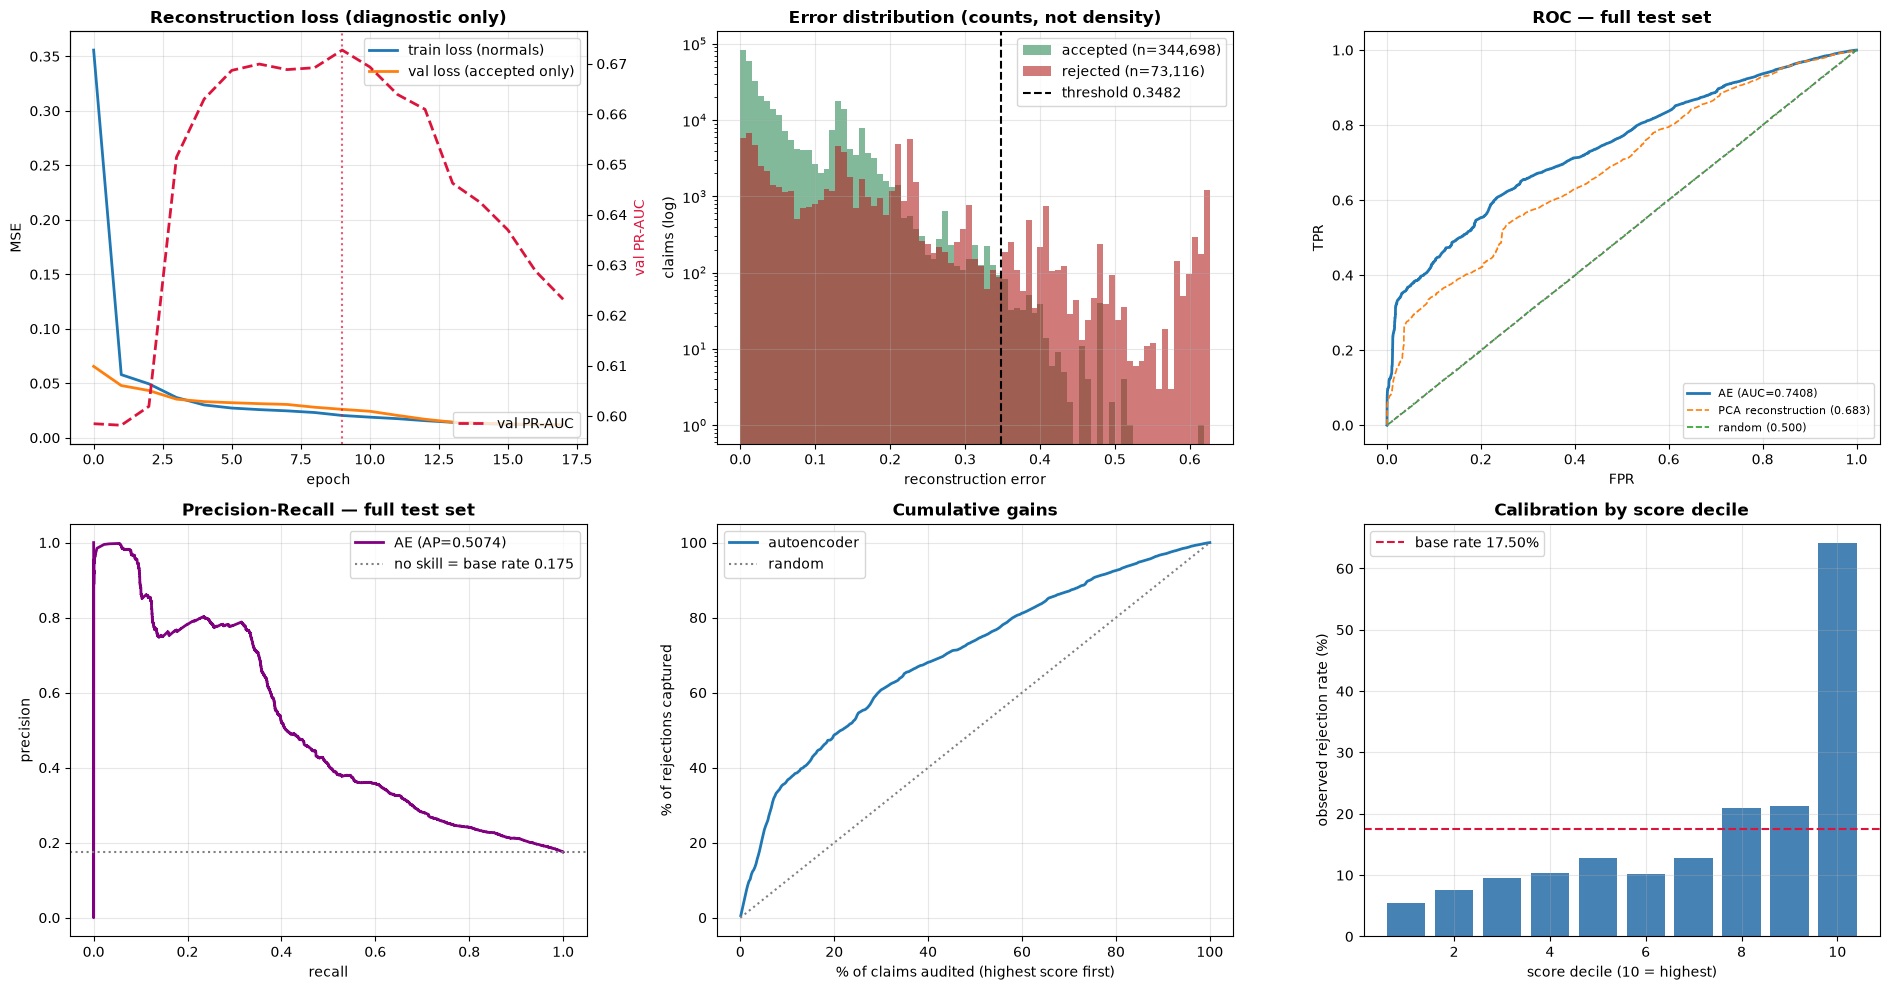

In [32]:
fig, ax = plt.subplots(2, 3, figsize=(19, 10))

# 1. training curves -- loss and the selection metric side by side
a = ax[0, 0]
a.plot(history["train_loss"], label="train loss (normals)", lw=2)
a.plot(history["val_loss_accepted"], label="val loss (accepted only)", lw=2)
a.set_xlabel("epoch"); a.set_ylabel("MSE"); a.legend(loc="upper right")
a.set_title("Reconstruction loss (diagnostic only)", fontweight="bold")
a2 = a.twinx()
a2.plot(history["val_ap"], color="crimson", ls="--", lw=2, label="val PR-AUC")
a2.set_ylabel("val PR-AUC", color="crimson")
a2.axvline(int(np.argmax(history["val_ap"])), color="crimson", ls=":", alpha=0.7)
a2.legend(loc="lower right")

# 2. error distribution -- COUNT scale, log y (D20)
a = ax[0, 1]
bins = np.linspace(0, np.percentile(test_errors, 99.5), 80)
a.hist(test_errors[y_test == 0], bins=bins, color="seagreen", alpha=0.6,
       label=f"accepted (n={int((y_test==0).sum()):,})")
a.hist(test_errors[y_test == 1], bins=bins, color="firebrick", alpha=0.6,
       label=f"rejected (n={int((y_test==1).sum()):,})")
a.axvline(THRESHOLD, color="black", ls="--", label=f"threshold {THRESHOLD:.4f}")
a.set_yscale("log"); a.set_xlabel("reconstruction error"); a.set_ylabel("claims (log)")
a.legend(); a.set_title("Error distribution (counts, not density)", fontweight="bold")

# 3. ROC on the full test set
a = ax[0, 2]
fpr, tpr, _ = roc_curve(y_test, test_errors)
a.plot(fpr, tpr, lw=2, label=f"AE (AUC={ROC_AUC:.4f})")
for nm, s in base.items():
    if nm.startswith(("PCA", "random")):
        a.plot(*roc_curve(y_test, s)[:2], lw=1.2, ls="--",
               label=f"{nm} ({roc_auc_score(y_test, s):.3f})")
a.plot([0, 1], [0, 1], color="grey", ls=":")
a.set_xlabel("FPR"); a.set_ylabel("TPR"); a.legend(loc="lower right", fontsize=8)
a.set_title("ROC — full test set", fontweight="bold")

# 4. PR on the full test set
a = ax[1, 0]
pr, rc_, _ = precision_recall_curve(y_test, test_errors)
a.plot(rc_, pr, lw=2, color="purple", label=f"AE (AP={PR_AUC:.4f})")
a.axhline(TEST_BASE_RATE, color="grey", ls=":",
          label=f"no skill = base rate {TEST_BASE_RATE:.3f}")
a.set_xlabel("recall"); a.set_ylabel("precision"); a.legend()
a.set_title("Precision-Recall — full test set", fontweight="bold")

# 5. lift / gains -- the chart auditors read
a = ax[1, 1]
kk = np.linspace(0.001, 1.0, 400)
gains = [cum[max(int(len(y_test)*k), 1) - 1] / max(y_test.sum(), 1) for k in kk]
a.plot(kk * 100, np.array(gains) * 100, lw=2, label="autoencoder")
a.plot([0, 100], [0, 100], color="grey", ls=":", label="random")
a.set_xlabel("% of claims audited (highest score first)")
a.set_ylabel("% of rejections captured")
a.legend(); a.set_title("Cumulative gains", fontweight="bold")

# 6. calibration -- score decile vs observed rate
a = ax[1, 2]
dec = pd.qcut(pd.Series(test_errors).rank(method="first"), 10, labels=False)
obs_rate = pd.Series(y_test).groupby(dec).mean()
a.bar(obs_rate.index + 1, obs_rate.values * 100, color="steelblue")
a.axhline(TEST_BASE_RATE * 100, color="crimson", ls="--",
          label=f"base rate {TEST_BASE_RATE:.2%}")
a.set_xlabel("score decile (10 = highest)"); a.set_ylabel("observed rejection rate (%)")
a.legend(); a.set_title("Calibration by score decile", fontweight="bold")

for r_ in ax:
    for a_ in r_:
        a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §17 — Facility-level view (D19)

The original ranked facilities by mean reconstruction error with no minimum volume, so a
facility with three claims could top the list. Two fixes: a minimum claim count, and
**empirical-Bayes shrinkage** toward the global mean, which pulls small-sample facilities
back toward the average in proportion to how little evidence supports them.

`Hfid` risk is also an input feature, so this view is partly circular. It is a monitoring
aid for spotting drift, not independent evidence about a facility.

In [33]:
fac = pd.DataFrame({"Hfid": hfid_test, "err": test_errors, "y": y_test,
                    "flagged": preds})
st = fac.groupby("Hfid").agg(claims=("err", "size"), mean_err=("err", "mean"),
                             flag_rate=("flagged", "mean"), rej_rate=("y", "mean")).reset_index()

g_mean = float(fac["err"].mean())
g_var  = float(st["mean_err"].var())
w_var  = float(fac.groupby("Hfid")["err"].var().mean())
k = w_var / max(g_var, 1e-12)                       # shrinkage constant
st["shrunk_err"] = ((st["claims"] * st["mean_err"] + k * g_mean) / (st["claims"] + k))

elig = st[st["claims"] >= CONFIG["MIN_FACILITY_CLAIMS"]].copy()
print(f"Facilities in test           : {len(st):,}")
print(f"With >= {CONFIG['MIN_FACILITY_CLAIMS']} claims        : {len(elig):,} "
      f"({len(elig)/len(st):.1%})")
print(f"Shrinkage constant k         : {k:,.1f} claims-equivalent")
print(f"\nExcluded for low volume      : {len(st)-len(elig):,} facilities "
      f"(median {st[st['claims'] < CONFIG['MIN_FACILITY_CLAIMS']]['claims'].median():.0f} claims)")
print("  -- in the original these dominated the top of the ranking\n")

print("TOP 15 FACILITIES BY SHRUNK MEAN RECONSTRUCTION ERROR")
print(elig.sort_values("shrunk_err", ascending=False).head(15)
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

print("\nFor comparison, the original's unfiltered raw-mean ranking would have returned:")
print(st.sort_values("mean_err", ascending=False).head(5)[["Hfid", "claims", "mean_err"]]
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

Facilities in test           : 878
With >= 100 claims        : 440 (50.1%)
Shrinkage constant k         : 0.6 claims-equivalent

Excluded for low volume      : 438 facilities (median 18 claims)
  -- in the original these dominated the top of the ranking

TOP 15 FACILITIES BY SHRUNK MEAN RECONSTRUCTION ERROR
 Hfid  claims  mean_err  flag_rate  rej_rate  shrunk_err
 3890     130    1.7061     0.7154    0.8846      1.6981
  449    4075    0.5986     0.9877    0.9728      0.5985
 3898     907    0.4278     0.7949    1.0000      0.4276
 3892    1531    0.3904     0.7988    0.7420      0.3903
  572     794    0.3351     0.5768    0.9962      0.3348
  832    1126    0.2507     0.0027    1.0000      0.2506
 3891     143    0.2349     0.0140    0.2587      0.2341
 1281     212    0.2295     0.0142    1.0000      0.2290
 2360    6003    0.2253     0.0000    1.0000      0.2253
  836    4514    0.2074     0.0000    1.0000      0.2074
 2372     195    0.1997     0.0000    0.9590      0.1993
 4406  

## §18 — Per-claim explanation

The reconstruction error is **already** an exact additive decomposition over features:

`error(x) = Σⱼ wⱼ (xⱼ − x̂ⱼ)² / Σⱼ wⱼ`

Each term sums exactly to the total, with no approximation, no background distribution and
no compute cost. For an autoencoder this is a better primary explanation than SHAP, which
approximates a scalar-output attribution and depends on the choice of background set. Use
SHAP as a secondary check for interaction effects that this decomposition cannot express.

Alongside each contribution the claim's raw value is shown against the accepted-population
median, since "6.8× the median for this diagnosis" is what an auditor can act on and
"squared error 0.0142" is not.

In [34]:
@torch.no_grad()
def explain_claim(pos, top_n=6):
    x = torch.tensor(X_test[pos:pos+1], dtype=torch.float32, device=device)
    model.eval()
    se = ((x - model(x)) ** 2).cpu().numpy().ravel()
    w = np.ones_like(se) if SCORE_W is None else SCORE_W
    contrib = se * w / w.sum()

    acc_med = np.median(X_test[y_test == 0], axis=0)
    o = np.argsort(-contrib)[:top_n]
    out = pd.DataFrame({
        "feature": [FEATURE_NAMES[j] for j in o],
        "scaled_value": X_test[pos, o],
        "accepted_median": acc_med[o],
        "z_vs_accepted": (X_test[pos, o] - acc_med[o]) /
                          np.maximum(X_test[y_test == 0][:, o].std(0), 1e-8),
        "error_contribution": contrib[o],
        "pct_of_total": contrib[o] / max(contrib.sum(), 1e-12) * 100,
    })
    return out, float(contrib.sum())

flagged = np.where(preds == 1)[0]
if len(flagged):
    pos = int(flagged[np.argmax(test_errors[flagged])])
    tbl, tot = explain_claim(pos)
    pctile = (test_errors < test_errors[pos]).mean() * 100
    print(f"Highest-scoring flagged claim (test row {pos:,})")
    print(f"  ClaimID            : {df['ClaimID'].values[idx_test][pos]}")
    print(f"  Facility (Hfid)    : {hfid_test[pos]}")
    print(f"  Anomaly score      : {test_errors[pos]:.6f}  "
          f"({pctile:.2f}nd percentile)")
    print(f"  Actual label       : {'REJECTED' if y_test[pos] else 'accepted'}"
          f"  (code {rej_test[pos]})")
    print(f"  Contributions sum  : {tot:.6f}  == score  [exact decomposition]\n")
    print(tbl.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

    print("\nAuditor-facing rendering:")
    for _, r in tbl.head(3).iterrows():
        d = "above" if r["z_vs_accepted"] > 0 else "below"
        print(f"  - {r['feature']}: {abs(r['z_vs_accepted']):.1f} sd {d} the accepted median "
              f"({r['pct_of_total']:.0f}% of the anomaly score)")
else:
    print("No claims flagged at the selected threshold.")

Highest-scoring flagged claim (test row 85,394)
  ClaimID            : 10723141
  Facility (Hfid)    : 352
  Anomaly score      : 7.810348  (100.00nd percentile)
  Actual label       : accepted  (code 0)
  Contributions sum  : 7.810349  == score  [exact decomposition]

            feature  scaled_value  accepted_median  z_vs_accepted  error_contribution  pct_of_total
   NUM_ServiceCount       22.1362           0.0000        87.4741              6.4383       82.4326
   NUM_LengthOfStay        0.0000           0.0000         0.0000              0.3729        4.7742
        Icdid__risk        0.6437           0.0261         1.3697              0.2968        3.8003
NUM_ClaimServiceGap      -16.6652           0.0000       -37.5493              0.2857        3.6578
        LegalForm=D        0.0000           0.0000         0.0000              0.0750        0.9608
         Hfid__risk        0.5860           0.0982         1.2329              0.0603        0.7725

Auditor-facing rendering:
  -

## §19 — Artefact export and model card

The exported config records **exactly** which decisions were made, including whether
post-adjudication features were used and which base rate the metrics were computed against.
The original config saved a threshold and an AUC with no record of either.

In [35]:
torch.save(model.state_dict(), MODEL_DIR / "autoencoder_best.pth")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(enc, MODEL_DIR / "encoders.pkl")
if SCORE_W is not None:
    np.save(MODEL_DIR / "score_weights.npy", SCORE_W)

export = {
    "created": _dt.datetime.now().isoformat(timespec="seconds"),
    "target": "ClaimStatus == 1 (claim REJECTION, not fraud)",
    "architecture": {"input_dim": int(X_train.shape[1]), "latent_dim": int(LATENT_DIM),
                     "hidden": list(CONFIG["HIDDEN"]),
                     "batchnorm": CONFIG["USE_BATCHNORM"],
                     "denoise_sigma": CONFIG["DENOISE_SIGMA"]},
    "score_mode": SCORE_MODE,
    "threshold": THRESHOLD,
    "threshold_mode": CONFIG["THRESHOLD_MODE"],
    "feature_names": FEATURE_NAMES,
    "split": {"mode": CONFIG["SPLIT_MODE"],
              "train_n": int(len(X_train_all)), "val_n": int(len(X_val)),
              "test_n": int(len(X_test))},
    "base_rates": {"population": POP_BASE_RATE, "validation": VAL_BASE_RATE,
                   "test": TEST_BASE_RATE},
    "metrics_test": {"roc_auc": float(ROC_AUC), "pr_auc": float(PR_AUC),
                     "precision": float(prec), "recall": float(rec), "f1": float(f1),
                     "alert_rate": float((tp+fp)/len(y_test)),
                     "roc_auc_ci95": [float(auc_lo), float(auc_hi)],
                     "pr_auc_ci95": [float(ap_lo), float(ap_hi)]},
    "seed_variance": {"test_auc_mean": float(seed_df["test_auc"].mean()),
                      "test_auc_std":  float(seed_df["test_auc"].std()),
                      "test_ap_mean":  float(seed_df["test_ap"].mean()),
                      "test_ap_std":   float(seed_df["test_ap"].std()),
                      "n_seeds": int(CONFIG["N_SEEDS"])},
    "baselines": bl.set_index("model")["PR_AUC"].to_dict(),
    "config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG.items()},
    "leakage_controls": {
        "post_adjudication_features_used": CONFIG["USE_POST_ADJUDICATION_FEATURES"],
        "encoders_fitted_on": "train window only",
        "scaler_fitted_on": "accepted training rows only",
        "max_feature_label_corr": float(cs.abs().max()),
    },
}
with open(MODEL_DIR / "autoencoder_config.json", "w") as f:
    json.dump(export, f, indent=2, default=str)

card = f"""# Model Card — Claim Rejection Autoencoder

**Created:** {export['created']}

## What this model does
Scores health insurance claims by autoencoder reconstruction error, trained on accepted
claims only. **The target is claim rejection, not fraud.** Per the openIMIS rejection
taxonomy, the large majority of rejections are deterministic eligibility and rule violations
already caught by the submission-time rules engine. See §15 for per-code detectability.

## Data
- Adjudicated claims only (accepted {CONFIG['ACCEPTED_STATUSES']}, rejected {CONFIG['REJECTED_STATUSES']})
- Split: {CONFIG['SPLIT_MODE']} — train {export['split']['train_n']:,} / val {export['split']['val_n']:,} / test {export['split']['test_n']:,}
- Base rates: population {POP_BASE_RATE:.4%}, test {TEST_BASE_RATE:.4%}

## Performance (test)
- ROC-AUC {ROC_AUC:.4f} (95% CI {auc_lo:.4f}–{auc_hi:.4f}, clustered by facility)
- PR-AUC {PR_AUC:.4f} vs no-skill {TEST_BASE_RATE:.4f} ({PR_AUC/TEST_BASE_RATE:.2f}x)
- At threshold {THRESHOLD:.6f}: precision {prec:.4f}, recall {rec:.4f}, alert rate {(tp+fp)/len(y_test):.2%}
- Across {CONFIG['N_SEEDS']} seeds: AUC {seed_df['test_auc'].mean():.4f} ± {seed_df['test_auc'].std():.4f}

## Leakage controls
- Post-adjudication features: {'USED — post-payment model only' if CONFIG['USE_POST_ADJUDICATION_FEATURES'] else 'excluded'}
- All encoders and scalers fitted on the training window only
- Max |corr(feature, label)|: {cs.abs().max():.4f}

## Known limitations
1. Rejection is a weak proxy for fraud; codes with AUC near 0.5 are structurally invisible.
2. The training "normal" class may still contain undetected historical overbilling.
3. Facility-level `Hfid` risk is an input, so §17 is partly circular.
4. False positives concentrate on high-complexity facilities; peer-group-relative scoring
   and a fairness audit are required before any operational use.
5. Not validated prospectively. A shadow pilot measuring precision against human
   adjudication is required before deployment.

## Intended use
Audit-queue triage alongside the existing rules engine. Advisory only; all decisions human.
**Not** an automated rejection or fraud-determination system.
"""
(MODEL_DIR / "MODEL_CARD.md").write_text(card, encoding="utf-8")

print(f"Artefacts written to {MODEL_DIR}:")
for p in ["autoencoder_best.pth", "scaler.pkl", "encoders.pkl",
          "autoencoder_config.json", "MODEL_CARD.md"]:
    fp = MODEL_DIR / p
    if fp.exists():
        print(f"  {p:<28} {fp.stat().st_size/1024:8.1f} KB")
print("\n" + card)

Artefacts written to C:\Projects\cameroon 3.0\model:
  autoencoder_best.pth             20.9 KB
  scaler.pkl                        1.0 KB
  encoders.pkl                     34.9 KB
  autoencoder_config.json           3.8 KB
  MODEL_CARD.md                     1.8 KB

# Model Card — Claim Rejection Autoencoder

**Created:** 2026-07-28T18:05:38

## What this model does
Scores health insurance claims by autoencoder reconstruction error, trained on accepted
claims only. **The target is claim rejection, not fraud.** Per the openIMIS rejection
taxonomy, the large majority of rejections are deterministic eligibility and rule violations
already caught by the submission-time rules engine. See §15 for per-code detectability.

## Data
- Adjudicated claims only (accepted (16, 32), rejected (1,))
- Split: temporal — train 1,949,796 / val 417,814 / test 417,814
- Base rates: population 15.8156%, test 17.4997%

## Performance (test)
- ROC-AUC 0.7408 (95% CI 0.6712–0.8015, clustered by facility)
- PR

## §20 — Scoring new claims

The inference path must reuse the **exact** transform chain — parser, encoders, scaler — that
was fitted in training. The original's deployment snippet applied `scaler.transform` to raw
values, which silently reintroduced the parsing bug at serving time.

In [36]:
def score_new_claims(raw_df, model, scaler, enc, weights=None, threshold=None):
    """Score a raw TblClaim-shaped frame. Mirrors §2 and §6 exactly."""
    raise NotImplementedError(
        "Refactor §2 (parse/engineer) and §6 (build_matrix) into importable functions "
        "and call them here. Do not re-implement the transforms -- divergence between "
        "training and serving preprocessing is the most common cause of silent "
        "production failure, and the original notebook's deployment snippet did exactly "
        "that by calling scaler.transform on unparsed raw values."
    )

print("Deployment checklist:")
for i, s in enumerate([
    "Package §2 and §6 as a single versioned transform module used by BOTH paths.",
    "Assert the serving feature vector matches config['feature_names'] in order and length.",
    "Log the score distribution daily; alert on PSI drift against the training window.",
    "Recalibrate the threshold to actual audit capacity, not to the value saved here.",
    "Track precision against human adjudication, not against the rejection label.",
    "Re-run the §4 audit gate on every retrain -- it is what catches D1/D2 recurrence.",
], 1):
    print(f"  {i}. {s}")

Deployment checklist:
  1. Package §2 and §6 as a single versioned transform module used by BOTH paths.
  2. Assert the serving feature vector matches config['feature_names'] in order and length.
  3. Log the score distribution daily; alert on PSI drift against the training window.
  4. Recalibrate the threshold to actual audit capacity, not to the value saved here.
  5. Track precision against human adjudication, not against the rejection label.
  6. Re-run the §4 audit gate on every retrain -- it is what catches D1/D2 recurrence.


---

## What this notebook does not fix

Three things are out of scope for an autoencoder rebuild and remain open:

1. **The target.** `ClaimStatus == 1` is rejection, not fraud. §15 quantifies how much of
   the target is structurally undetectable. The higher-value targets are the financial
   deduction signal (653M XAF across 1.2M *accepted* claims) and the 412,890 line items with
   `PriceAsked / ServPrice > 1.5`.
2. **The unit of analysis.** Healthcare fraud is organised at provider level. A claim-level
   i.i.d. score cannot see collusion, phantom billing patterns or systematic unbundling.
   Aggregating to ~30k facility-month profiles and running HDBSCAN + GLOSH there is cheap
   and likely to produce more actionable findings than any per-claim model.
3. **Prospective validation.** Every number here is retrospective against a label that
   partly encodes rules already enforced upstream. Only a shadow pilot scored against
   independent human adjudication measures what you actually care about.